# Paper visuals

Every figure the paper uses out of the notebooks `06`/`07`/`08`, in paper order. Run top to
bottom from `src/`; each section writes its PDF under `visuals/`.

| section | file | paper figure |
|---|---|---|
| 1 | `visuals/machine_value_curve_two_runs.pdf` | `4_machine_activites.pdf` |
| 2 | `visuals/step_dtw_method.pdf` | `5_step_dtw_method.pdf` |
| 3 | `visuals/predicted_vs_real_autoclave_cooling_realism_process_1.pdf` | `8_process_energy_visual.pdf` |
| 4 | `visuals/process_and_profiles/paper_figure_combined.pdf` | `9_process_and_profiles.pdf` |

Sections 3 and 4 read a pipeline run under `../results` (`RUN` in their config cells);
sections 1 and 2 are synthetic and need no data.


## 1. Material flow vs machine activities — two runs


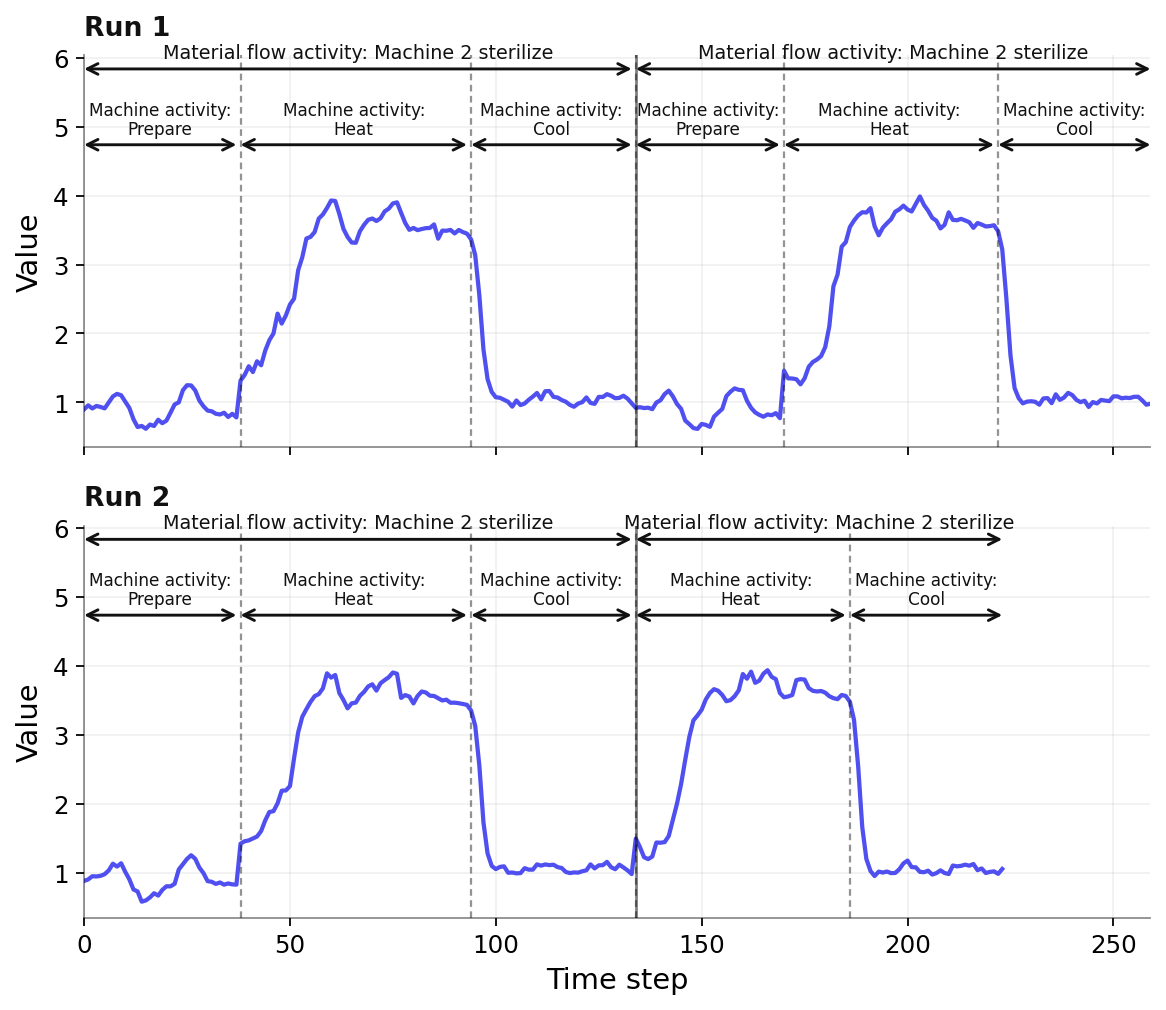

Saved visual to: visuals/machine_value_curve_two_runs.pdf


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(12)

# ============================================================
# Output folder
# ============================================================
os.makedirs("visuals", exist_ok=True)

# ============================================================
# Plot style
# ============================================================
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 160,
})


# ============================================================
# Activity generators (parameterized so cycles can differ)
# ============================================================
def make_prepare(n):
    t = np.linspace(0, 1, n)
    peak_1 = 0.28 * np.exp(-0.5 * ((t - 0.22) / 0.07) ** 2)
    valley = -0.18 * np.exp(-0.5 * ((t - 0.48) / 0.08) ** 2)
    peak_2 = 0.34 * np.exp(-0.5 * ((t - 0.72) / 0.09) ** 2)
    return (0.82
            + 0.08 * np.sin(4 * np.pi * t + 0.3)
            + 0.05 * np.sin(9 * np.pi * t + 0.8)
            + peak_1 + valley + peak_2
            + 0.030 * np.random.randn(n))


def make_heat(n, ramp_speed=16.0, ramp_center=0.18, load=2.35,
              peak_pos=(0.42, 0.72), peak_amp=(0.35, 0.28),
              osc_amp=0.18, phase=0.0):
    t = np.linspace(0, 1, n)
    ramp_up = 1 / (1 + np.exp(-ramp_speed * (t - ramp_center)))
    main_load = 1.10 + load * ramp_up
    oscillation = (osc_amp * np.sin(7 * np.pi * t + phase)
                   + 0.10 * np.sin(15 * np.pi * t + 0.7 + phase))
    peaks = (peak_amp[0] * np.exp(-0.5 * ((t - peak_pos[0]) / 0.08) ** 2)
             + peak_amp[1] * np.exp(-0.5 * ((t - peak_pos[1]) / 0.10) ** 2))
    # Fade fluctuations out at the end so heating settles on a flat plateau
    fade = 1 / (1 + np.exp(28 * (t - 0.86)))
    noise = 0.055 * np.random.randn(n) * (0.30 + 0.70 * fade)
    return main_load + (oscillation + peaks) * fade + noise


def make_cool(n, start_value, drop_speed=55.0, drop_at=0.06,
              base=1.05, phase=0.5):
    # Starts exactly where Heat ended, then steps sharply down to idle
    t = np.linspace(0, 1, n)
    high = 1 / (1 + np.exp(drop_speed * (t - drop_at)))
    step_down = (start_value - base) * high
    ripple = (0.06 * np.sin(5 * np.pi * t + phase)
              + 0.035 * np.random.randn(n))
    return base + step_down + ripple * (1 - high)


# ============================================================
# Build runs as sequences of (activity name, values)
# ============================================================
# ---- Run 1: Prepare, Heat, Cool | Prepare, Heat, Cool ----
r1_heat_a = make_heat(56)
r1_cool_a = make_cool(40, start_value=r1_heat_a[-1])
r1_heat_b = make_heat(52, ramp_center=0.22, load=2.45,
                      peak_pos=(0.38, 0.68), phase=0.9)
r1_cool_b = make_cool(38, start_value=r1_heat_b[-1], phase=1.2)

run1_activities = [
    ("Prepare", make_prepare(38)),
    ("Heat", r1_heat_a),
    ("Cool", r1_cool_a),
    ("Prepare", make_prepare(36)),
    ("Heat", r1_heat_b),
    ("Cool", r1_cool_b),
]

# ---- Run 2: Prepare, Heat, Cool | Heat, Cool (no 2nd Prepare) ----
r2_heat_a = make_heat(56, phase=0.4)
r2_cool_a = make_cool(40, start_value=r2_heat_a[-1], phase=0.8)
r2_heat_b = make_heat(52, ramp_center=0.22, load=2.45,
                      peak_pos=(0.38, 0.68), phase=1.6)
r2_cool_b = make_cool(38, start_value=r2_heat_b[-1], phase=1.9)

run2_activities = [
    ("Prepare", make_prepare(38)),
    ("Heat", r2_heat_a),
    ("Cool", r2_cool_a),
    ("Heat", r2_heat_b),
    ("Cool", r2_cool_b),
]

# Sterilize cycles per run: number of activities in each cycle
run1_cycles = [3, 3]   # (Prepare, Heat, Cool) | (Prepare, Heat, Cool)
run2_cycles = [3, 2]   # (Prepare, Heat, Cool) | (Heat, Cool)

runs = [("Run 1", run1_activities, run1_cycles),
        ("Run 2", run2_activities, run2_cycles)]

# ============================================================
# Assemble values and segment boundaries per run
# ============================================================
assembled = []
for run_name, activities, cycles in runs:
    value = np.clip(np.concatenate([v for _, v in activities]), 0.05, None)

    segments, pos = [], 0
    for name, v in activities:
        segments.append((name, pos, pos + len(v) - 1))
        pos += len(v)

    flows, idx = [], 0
    for n_acts in cycles:
        flows.append((segments[idx][1], segments[idx + n_acts - 1][2]))
        idx += n_acts

    assembled.append((run_name, value, segments, flows))

# ============================================================
# Plot: two runs stacked, compact format for the paper
# ============================================================
max_len = max(len(v) for _, v, _, _ in assembled)

fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.0), sharex=True,
                         gridspec_kw={"hspace": 0.20})

curve_color = "#4545F0"
line_color = "#111111"
curve_lw = 1.9
bar_lw = 1.3

y_min = 0.35
y_max = max(v.max() for _, v, _, _ in assembled) + 2.05
material_bar_y = y_max - 0.20
material_text_y = material_bar_y + 0.10
activity_bar_y = y_max - 1.30
activity_text_y = activity_bar_y + 0.10

for ax, (run_name, value, segments, flows) in zip(axes, assembled):
    x = np.arange(len(value))

    ax.plot(x, value, color=curve_color, linewidth=curve_lw, alpha=0.94)
    ax.set_ylabel("Value", fontsize=13)
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0, max_len - 1)
    ax.set_title(run_name, fontsize=12, fontweight="bold",
                 loc="left", pad=9, color=line_color)

    # Material-flow intervals (one per sterilize cycle)
    for start, end in flows:
        ax.annotate("", xy=(start, material_bar_y), xytext=(end, material_bar_y),
                    arrowprops=dict(arrowstyle="<->", color=line_color,
                                    linewidth=bar_lw, shrinkA=0, shrinkB=0))
        ax.text((start + end) / 2, material_text_y,
                "Material flow activity: Machine 2 sterilize",
                ha="center", va="bottom", fontsize=8.6, color=line_color)

    # Machine activity intervals
    for name, start, end in segments:
        ax.annotate("", xy=(start, activity_bar_y), xytext=(end, activity_bar_y),
                    arrowprops=dict(arrowstyle="<->", color=line_color,
                                    linewidth=bar_lw, shrinkA=0, shrinkB=0))
        ax.text((start + end) / 2, activity_text_y,
                f"Machine activity:\n{name}", ha="center", va="bottom",
                fontsize=7.6, linespacing=1.05, color=line_color)

    # Dashed separators between machine activities
    for _, start, _ in segments[1:]:
        ax.axvline(start, color=line_color, linestyle=(0, (3, 2)),
                   linewidth=1.0, alpha=0.45)

    # Solid separator between the two sterilize cycles
    ax.axvline(flows[1][0], color=line_color, linestyle="-",
               linewidth=1.2, alpha=0.55)

    ax.grid(True, alpha=0.18)
    ax.set_facecolor("white")
    ax.spines["left"].set_alpha(0.45)
    ax.spines["bottom"].set_alpha(0.45)

axes[-1].set_xlabel("Time step", fontsize=13)
fig.patch.set_facecolor("white")

# ============================================================
# Save high-resolution PDF
# ============================================================
pdf_path = os.path.join("visuals", "machine_value_curve_two_runs.pdf")

plt.savefig(pdf_path, format="pdf", bbox_inches="tight",
            dpi=600, facecolor="white")

plt.show()

print(f"Saved visual to: {pdf_path}")


## 2. Step DTW method

(a) reference curve $r$ = DTW medoid of the activity's executions; (b) $r$ segmented once by
change-point detection (DP + BIC); (c) the breakpoints carried onto every training curve by DTW,
giving its targets $(\phi, \lambda)$; (d) a new execution rebuilt from predicted $(\phi, \lambda)$.


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



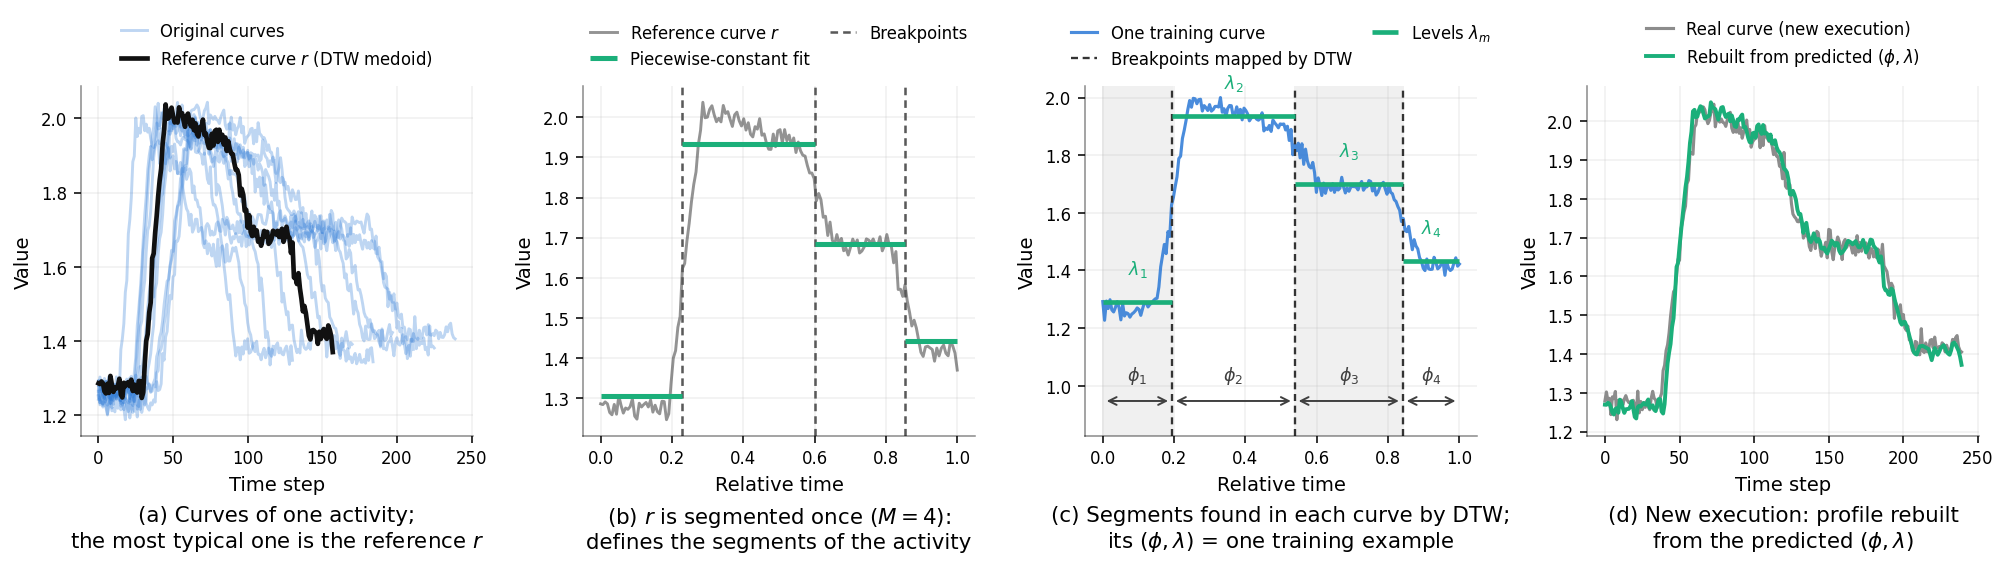

Saved visual to: visuals/step_dtw_method.pdf
Medoid: curve 5 | segments M=4 | breakpoints b=[0.228 0.602 0.854]

Panel notes for LaTeX:
(a) Executions of one activity with different lengths, phase timings and levels; the reference curve r is the DTW medoid, a real execution.
(b) The reference is segmented once by change-point detection into M segments.
(c) The breakpoints are carried through the DTW warping path onto each training curve, giving its ML targets: segment duration fractions and segment levels.
(d) For a new execution the ML models predict the durations and levels; the reference is warped onto the predicted durations and modulated by the level gains interpolated between the segment midpoints, so the reference's transitions and texture survive without reconstruction jumps.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from dtw import dtw

# ============================================================
# Step DTW smooth method explanation visual
# ============================================================
# The energy model parameterises each activity profile as M segments.
# (a) the reference curve r is a REAL execution: the DTW medoid;
# (b) r is segmented once by change-point detection (DP + BIC);
# (c) the breakpoints are carried by DTW onto each training curve,
#     giving its targets: duration fractions phi and levels lambda;
# (d) for a new execution the ML models predict (phi, lambda) and the
#     profile is rebuilt: the reference is warped onto the predicted
#     durations and modulated by the smoothly interpolated level gains.
# ============================================================

np.random.seed(7)
os.makedirs("visuals", exist_ok=True)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 140,
})


def moving_average(y, window=7):
    y = np.asarray(y, dtype=float)
    if window <= 1:
        return y.copy()
    pad = window // 2
    y_pad = np.pad(y, pad_width=pad, mode="edge")
    return np.convolve(y_pad, np.ones(window) / window, mode="valid")


def linear_resample(y, fixed_length):
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, fixed_length)
    return np.interp(x_new, x_old, y)


def make_step_curve(n):
    """
    One raw curve with a phase structure: idle -> high -> hold -> low.

    Executions of the SAME activity: the phase levels barely move, only
    the total length and the phase durations vary. Wide smoothing turns
    the level changes into rounded, curve-like transitions, and the
    within-phase texture (decay ramp, duty cycling) recurs.
    """
    fracs = np.array([0.22, 0.34, 0.28, 0.16])
    fracs = fracs * np.random.uniform(0.85, 1.18, size=4)
    fracs = fracs / fracs.sum()

    levels = np.array([1.25, 1.95, 1.70, 1.40])
    levels = levels * np.random.uniform(0.98, 1.02, size=4)
    levels = np.random.uniform(0.99, 1.01) * levels + np.random.uniform(-0.02, 0.03)

    edges = np.round(np.concatenate([[0.0], np.cumsum(fracs)]) * n).astype(int)
    edges[-1] = n

    y = np.empty(n)
    for m in range(4):
        a, b = edges[m], edges[m + 1]
        u = np.linspace(0, 1, max(b - a, 1))
        seg = np.full(b - a, levels[m])
        if m == 1:
            seg = seg * (1.03 - 0.06 * u)           # gentle decay in the high phase
        if m == 2:
            seg = seg * (1.0 + 0.02 * np.sin(2 * np.pi * 3 * u))  # duty cycling
        y[a:b] = seg

    y = moving_average(y, window=max(7, n // 10) | 1)   # rounded, curve-like transitions
    y += 0.018 * np.random.randn(n)
    return {"raw_values": np.clip(y, 0.05, None), "length": n}


def segment_reference(shape, max_segments=8):
    """
    Interior breakpoints (fractions) of the best piecewise-constant
    approximation of `shape`: exact DP under an L2 cost, the number of
    segments chosen by a BIC-style penalty.
    """
    y = np.asarray(shape, dtype=float)
    L = len(y)
    min_seg = max(3, L // 8)
    m_max = max(1, min(max_segments, L // min_seg))

    c1 = np.concatenate([[0.0], np.cumsum(y)])
    c2 = np.concatenate([[0.0], np.cumsum(y * y)])
    cost = np.full((m_max + 1, L + 1), np.inf)
    back = np.zeros((m_max + 1, L + 1), dtype=int)
    cost[0, 0] = 0.0
    for m in range(1, m_max + 1):
        for j in range(m * min_seg, L + 1):
            i = np.arange((m - 1) * min_seg, j - min_seg + 1)
            s = c1[j] - c1[i]
            tot = cost[m - 1, i] + (c2[j] - c2[i]) - s * s / (j - i)
            a = int(np.argmin(tot))
            cost[m, j], back[m, j] = tot[a], i[a]

    rss = cost[1:, L]
    ms = np.arange(1, m_max + 1)
    bic = L * np.log(np.maximum(rss, 1e-12) / L) + 2.0 * ms * np.log(L)
    best_m = int(ms[np.argmin(bic)])

    cuts = []
    j = L
    for m in range(best_m, 0, -1):
        i = int(back[m, j])
        if 0 < i < L:
            cuts.append(i)
        j = i
    return np.array(sorted(c / L for c in cuts))


def transfer_breaks(ref_shape, curve_shape, break_fracs):
    """
    Carry the reference breakpoints through the DTW warping path onto
    the curve's own (relative) timeline.
    """
    alignment = dtw(np.asarray(ref_shape).reshape(-1, 1),
                    np.asarray(curve_shape).reshape(-1, 1),
                    keep_internals=True)
    i_ref = np.asarray(alignment.index1)
    i_cur = np.asarray(alignment.index2)

    pos = []
    for b in break_fracs:
        ib = int(round(b * (len(ref_shape) - 1)))
        matched = i_cur[i_ref == ib]
        pos.append(np.mean(matched) / (len(curve_shape) - 1))
    return np.clip(np.maximum.accumulate(np.array(pos)), 0.0, 1.0)


def segment_targets(raw_values, break_pos):
    """
    Duration fractions and mean raw levels of the M segments. A small
    interior margin keeps transition samples out of the level means.
    """
    n = len(raw_values)
    edges = np.concatenate([[0.0], break_pos, [1.0]])
    durations = np.diff(edges)
    trim = max(1, n // 40)
    levels = []
    for m in range(len(durations)):
        i0 = min(int(np.floor(edges[m] * n)), n - 1)
        i1 = max(int(np.ceil(edges[m + 1] * n)), i0 + 1)
        if i1 - i0 > 3 * trim:
            i0, i1 = i0 + trim, i1 - trim
        levels.append(np.mean(raw_values[i0:i1]))
    return durations, np.array(levels)


def reconstruct_smooth(medoid_values, medoid_breaks, durations, levels, n):
    """
    Smooth reconstruction (Step DTW smooth): boundaries at the normalised
    cumulative durations; the reference is read through ONE piecewise-
    linear time warp (output edges -> reference edges) and interpolated
    continuously; the predicted levels act as a gain envelope evaluated
    at the segment midpoints and interpolated linearly across the curve.
    """
    d = np.clip(durations, 0.0, None)
    d = d / d.sum()
    edges = np.round(np.cumsum(np.concatenate([[0.0], d])) * n).astype(int)
    edges[0], edges[-1] = 0, n
    edges = np.maximum.accumulate(edges)

    med = np.asarray(medoid_values, dtype=float)
    Lm = len(med)
    med_edges = np.concatenate([[0.0], medoid_breaks, [1.0]])

    xs = edges.astype(float) / n
    keep = np.r_[xs[1:] != xs[:-1], True]
    pos = np.interp((np.arange(n) + 0.5) / n, xs[keep], med_edges[keep])
    base = np.interp(pos, np.linspace(0.0, 1.0, Lm), med)

    mids, gains = [], []
    for m in range(len(d)):
        a, b = edges[m], edges[m + 1]
        if b <= a:
            continue
        mu = float(np.mean(base[a:b]))
        if abs(mu) > 1e-12:
            mids.append((a + b - 1) / 2.0)
            gains.append(levels[m] / mu)
    return base * np.interp(np.arange(n, dtype=float), mids, gains)


# ============================================================
# Create curves, select the medoid, segment, transfer, reconstruct
# ============================================================
lengths = [105, 118, 131, 144, 158, 171, 185, 198, 212, 226, 240]
training_curves = [make_step_curve(n) for n in lengths]

S = int(np.median(lengths))
for c in training_curves:
    res = linear_resample(c["raw_values"], S)
    c["shape"] = res / np.mean(res)

# DTW medoid: the real curve with the smallest total DTW distance.
n_curves = len(training_curves)
D = np.zeros((n_curves, n_curves))
for i in range(n_curves):
    for j in range(i + 1, n_curves):
        d_ij = dtw(training_curves[i]["shape"].reshape(-1, 1),
                   training_curves[j]["shape"].reshape(-1, 1),
                   distance_only=True).distance
        D[i, j] = D[j, i] = d_ij
medoid_idx = int(D.sum(axis=1).argmin())
medoid = training_curves[medoid_idx]

# Segment the reference once; carry the breakpoints onto every curve.
break_fracs = segment_reference(medoid["shape"])
M = len(break_fracs) + 1

for k, c in enumerate(training_curves):
    if k == medoid_idx:
        c["break_pos"] = break_fracs.copy()
    else:
        c["break_pos"] = transfer_breaks(medoid["shape"], c["shape"], break_fracs)
    c["durations"], c["levels"] = segment_targets(c["raw_values"], c["break_pos"])

# (c) shows the targets of ONE training curve; (d) rebuilds ANOTHER
# execution from its (phi, lambda) as if the ML models predicted them.
target_demo = training_curves[7]
new_case = training_curves[-1]
new_recon = reconstruct_smooth(medoid["raw_values"], break_fracs,
                               new_case["durations"], new_case["levels"],
                               new_case["length"])


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.3))

curve_color = "#2a78d6"    # categorical slot 1 (blue)
ref_color = "#111111"
accent_color = "#1baf7a"   # categorical slot 3 (green)
title_y = -0.20


def legend_above(ax, ncol):
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=ncol,
              frameon=False, columnspacing=1.2, handlelength=1.6)


# (a) Raw curves and the reference curve r (DTW medoid)
for k, c in enumerate(training_curves):
    axes[0].plot(np.arange(c["length"]), c["raw_values"],
                 color=curve_color, alpha=0.30, linewidth=1.5,
                 label="Original curves" if k == 0 else None)
axes[0].plot(np.arange(medoid["length"]), medoid["raw_values"],
             color=ref_color, linewidth=2.4, zorder=10,
             label="Reference curve $r$ (DTW medoid)")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Value")
legend_above(axes[0], ncol=1)
axes[0].text(0.5, title_y, "(a) Curves of one activity;\n"
             "the most typical one is the reference $r$",
             transform=axes[0].transAxes, ha="center", va="top", fontsize=11)

# (b) Change-point segmentation of the reference
t_ref = np.linspace(0, 1, medoid["length"])
axes[1].plot(t_ref, medoid["raw_values"], color=ref_color, alpha=0.45,
             linewidth=1.5, label="Reference curve $r$")
edges_ref = np.concatenate([[0.0], break_fracs, [1.0]])
for m in range(M):
    i0 = int(np.floor(edges_ref[m] * medoid["length"]))
    i1 = max(int(np.ceil(edges_ref[m + 1] * medoid["length"])), i0 + 1)
    lvl = np.mean(medoid["raw_values"][i0:i1])
    axes[1].hlines(lvl, edges_ref[m], edges_ref[m + 1], color=accent_color,
                   linewidth=2.6, zorder=10,
                   label="Piecewise-constant fit" if m == 0 else None)
for i, b in enumerate(break_fracs):
    axes[1].axvline(b, color="0.35", linestyle=(0, (3, 2)), linewidth=1.3,
                    label="Breakpoints" if i == 0 else None)
axes[1].set_xlabel("Relative time")
axes[1].set_ylabel("Value")
legend_above(axes[1], ncol=2)
axes[1].text(0.5, title_y, f"(b) $r$ is segmented once ($M={M}$):\n"
             "defines the segments of the activity",
             transform=axes[1].transAxes, ha="center", va="top", fontsize=11)

# (c) One training curve: the segments are found in ITS timeline by DTW,
#     and its own numbers (phi, lambda) are read off = one training example
c = target_demo
t = np.linspace(0, 1, c["length"])
edges_c = np.concatenate([[0.0], c["break_pos"], [1.0]])
for m in range(M):
    if m % 2 == 0:
        axes[2].axvspan(edges_c[m], edges_c[m + 1], color="0.94", zorder=0)
axes[2].plot(t, c["raw_values"], color=curve_color, alpha=0.85,
             linewidth=1.6, label="One training curve")
y_min = c["raw_values"].min() - 0.28
for i, bp in enumerate(c["break_pos"]):
    axes[2].axvline(bp, color="0.2", linestyle=(0, (3, 2)), linewidth=1.2,
                    label="Breakpoints mapped by DTW" if i == 0 else None)
for m in range(M):
    axes[2].hlines(c["levels"][m], edges_c[m], edges_c[m + 1],
                   color=accent_color, linewidth=2.4, zorder=10,
                   label="Levels $\\lambda_m$" if m == 0 else None)
    x_mid = 0.5 * (edges_c[m] + edges_c[m + 1])
    axes[2].text(x_mid, c["levels"][m] + 0.08, f"$\\lambda_{m + 1}$",
                 ha="center", va="bottom", fontsize=9, color=accent_color)
    axes[2].annotate("", xy=(edges_c[m], y_min), xytext=(edges_c[m + 1], y_min),
                     arrowprops=dict(arrowstyle="<->", color="0.25", lw=1.0))
    axes[2].text(x_mid, y_min + 0.05, f"$\\phi_{m + 1}$",
                 ha="center", va="bottom", fontsize=9, color="0.25")
axes[2].set_ylim(bottom=y_min - 0.12)
axes[2].set_xlabel("Relative time")
axes[2].set_ylabel("Value")
legend_above(axes[2], ncol=2)
axes[2].text(0.5, title_y, "(c) Segments found in each curve by DTW;\n"
             "its $(\\phi, \\lambda)$ = one training example",
             transform=axes[2].transAxes, ha="center", va="top", fontsize=11)

# (d) A new execution rebuilt from predicted (phi, lambda)
axes[3].plot(np.arange(new_case["length"]), new_case["raw_values"],
             color="0.55", linewidth=1.6, label="Real curve (new execution)")
axes[3].plot(np.arange(new_case["length"]), new_recon, color=accent_color,
             linewidth=2.0, zorder=10,
             label="Rebuilt from predicted $(\\phi, \\lambda)$")
axes[3].set_xlabel("Time step")
axes[3].set_ylabel("Value")
legend_above(axes[3], ncol=1)
axes[3].text(0.5, title_y, "(d) New execution: profile rebuilt\n"
             "from the predicted $(\\phi, \\lambda)$",
             transform=axes[3].transAxes, ha="center", va="top", fontsize=11)

for ax in axes:
    ax.grid(True, alpha=0.18)
    ax.spines["left"].set_alpha(0.45)
    ax.spines["bottom"].set_alpha(0.45)

plt.subplots_adjust(bottom=0.24, top=0.82, wspace=0.28)

pdf_path = os.path.join("visuals", "step_dtw_method.pdf")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=600,
            facecolor="white")
plt.show()

print(f"Saved visual to: {pdf_path}")
print(f"Medoid: curve {medoid_idx + 1} | segments M={M} | breakpoints b={np.round(break_fracs, 3)}")

panel_notes = {
    "(a)": "Executions of one activity with different lengths, phase timings and "
           "levels; the reference curve r is the DTW medoid, a real execution.",
    "(b)": "The reference is segmented once by change-point detection into M segments.",
    "(c)": "The breakpoints are carried through the DTW warping path onto each "
           "training curve, giving its ML targets: segment duration "
           "fractions and segment levels.",
    "(d)": "For a new execution the ML models predict the durations and levels; "
           "the reference is warped onto the predicted durations and modulated by "
           "the level gains interpolated between the segment midpoints, so the "
           "reference's transitions and texture survive without reconstruction jumps.",
}
print("\nPanel notes for LaTeX:")
for key, text in panel_notes.items():
    print(f"{key} {text}")

## 3. Predicted vs real profiles — autoclave cooling water

Real profile against each approach for a few test cases, with the realism error of each approach
next to its curve and the activity schedule that produced it underneath.


In [4]:
# -- Config --------------------------------------------------------------------
PROCESS = 'process_1'
N_CASES = 4          # how many real test cases to show per sensor
#CASES   = ['batch_274', 'batch_261', 'batch_220']      # None = pick automatically (see CASE_PICK); or name them
                     # explicitly, e.g. ['batch_211', 'batch_240', 'batch_263']
                     # The full list of available cases is printed below.
CASE_PICK = 'spread' # 'spread' = shortest / longest and evenly spaced in between
                     # 'random' = random sample driven by RANDOM_STATE
SENSORS = None       # None = auto-pick; or set explicitly, e.g. ['destillation_steam_demand_kW_energy_to_model']
EXCLUDE_SENSORS = ['bottling_power_kW_energy_to_model']   # dropped from the figures
RANDOM_STATE = 42

# -- Which run to read ---------------------------------------------------------
# None = latest run that has the curves this notebook needs (previous behaviour).
# Otherwise the run to use, by full directory name or by any substring of it:
#   RUN = 'experiment_964'                      -> latest run matching that
#   RUN = 'experiment_964_20260723_190547'      -> exactly that run
RUN = 'experiment_1'

# -- Which series to draw, in this order (legend, drawing and strip order) ----
#   Best Net + Budget -- best discovered net + total-duration budgeting
#   Best Net          -- best discovered net
#   Alpha             -- naive alpha-miner net
#                        but the Step DTW curve predictor the nets use, so the
#                        gap to the nets prices the process model alone
#   Profile-generator -- stochastic per-position generator, no conditioning
SERIES_TO_SHOW = ['Real', 'Best Net + Budget', 'Best Net', 'Alpha',
                  'Profile-generator']

# The mean panel next to each curve: 'case' divides the curve's integral by the
# FULL case span (a predicted curve that only covers the autoclave window counts
# as 0 elsewhere, so the means are comparable across methods); 'curve' divides by
# each curve's own span, which rewards methods that simply predict less.
MEAN_OVER = 'case'       # 'case' | 'curve'

PLOT_STYLE = 'overlay'   # 'overlay' = all methods in one axes (+ activity strips)
                         # 'facet'   = one small panel per method, real greyed behind

# -- How the nets are chosen ---------------------------------------------------
# This notebook only VISUALIZES, it reports no numbers, so picking the model on
# TEST is fine here -- it shows what the best model actually does on the cases
# being plotted. Set SELECT_ON = 'train' to show exactly the models the tables
# in 03_results_process.ipynb / the paper are selected on.
SELECT_ON = 'test'       # 'test' | 'train' -- split used to pick Best Net + time variant
TIME_PRED = 'best'       # 'best' = lowest <SELECT_ON>_overall_error per net,
                         # or fix it: 'baseline' | 'ml_global' | 'ml_local'
CURVE_APPROACH      = 'ml_step_dtw_smooth'   # curve predictor for the three nets

# The curve-approach FILE NAME differs between runs: the approach now called
# 'ml_external' was written as 'ml_exog_prev_activity' before the rename (same
# method, same features -- only the key changed), and likewise for the seq2seq
# variant. Every run older than the rename therefore carries the old file name,
# and asking for 'ml_external' alone finds nothing there. The loader below tries
# each alias in order and uses the first that exists on disk; add a pair here if
# an approach is renamed again.
CURVE_APPROACH_ALIASES = {
    'ml_external':      ['ml_external', 'ml_exog_prev_activity'],
    'seq2seq_external': ['seq2seq_external', 'seq2seq_prev_activity'],
}

In [5]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)
plt.rcParams.update(plt.rcParamsDefault)   # sections 1-2 changed them

results_root = Path('..') / 'results'

# Runs that actually have the schedule curves this notebook starts from.
_candidates = [d for d in sorted(results_root.iterdir())
               if d.is_dir()
               and (d / 'schedule_profile_eval_results' / PROCESS / 'predicted_curves.parquet').exists()]
assert _candidates, f'No run found with schedule_profile_eval_results/{PROCESS}/predicted_curves.parquet'

if RUN:
    # Explicit pick: exact directory name, or any substring of it (latest match).
    # Tiered on purpose: a bare substring makes 'experiment_1' match
    # experiment_1000 and the retired experiment_1_old / _failed dirs, and those
    # sort AFTER a timestamp ('o'/'f'/'0' > the digits), so _matches[-1] returned
    # a stale run. Exact name first, then '<RUN>_<YYYYMMDD>_<HHMMSS>', then the
    # loose substring as a last resort.
    _matches = [d for d in _candidates if d.name == RUN] or \
               [d for d in _candidates
                if re.fullmatch(rf'{re.escape(RUN)}_\d{{8}}_\d{{6}}', d.name)] or \
               [d for d in _candidates if RUN in d.name]
    if not _matches:
        raise AssertionError(
            f'RUN={RUN!r} matches no run with curves for {PROCESS}.\n'
            f'Available: ' + ', '.join(d.name for d in _candidates))
    run_dir = _matches[-1]
else:
    run_dir = _candidates[-1]
print(f'Using run: {run_dir.name}' + ('' if RUN else '   (latest; set RUN to pin one)'))

curves_path = run_dir / 'schedule_profile_eval_results' / PROCESS / 'predicted_curves.parquet'
df_curves = pd.read_parquet(curves_path)
print(f'{len(df_curves)} rows | sensors: {sorted(df_curves["sensor"].unique())} | '
      f'{df_curves["case_id"].nunique()} cases | series: {sorted(df_curves["series"].unique())}')

Using run: experiment_1_20260804_161749
424272 rows | sensors: ['autoclave_cooling_water_demand_kW_energy_to_model', 'autoclave_steam_demand_kW_energy_to_model', 'bottling_power_kW_energy_to_model', 'destillation_cooling_demand_kW_energy_to_model', 'destillation_steam_demand_kW_energy_to_model', 'individual_packaging_power_kW_energy_to_model'] | 90 cases | series: ['best', 'best_budget', 'best_duration_corrected', 'bootstrap', 'real', 'stochastic']


In [6]:
# -- Add the simulated series to df_curves ------------------------------------
# All curve files share the (case_id, sensor, t_minutes) convention -- minutes
# since that curve's own case start -- so they drop straight into df_curves.
# The three nets differ ONLY in the net, so they are directly comparable.
_TIME_SUFFIX = {'baseline': '', 'ml_global': '_ml_plus_global', 'ml_local': '_ml_plus_per_act'}

# Candidate file names for the requested curve approach, in preference order
# (see CURVE_APPROACH_ALIASES: the same method was written under a different
# name before the rename, so a run older than it carries the old file).
_approach_names = (['']
                   if CURVE_APPROACH in ('baseline', '', None)
                   else CURVE_APPROACH_ALIASES.get(CURVE_APPROACH, [CURVE_APPROACH]))

def _curve_file(mode_dir):
    """First existing predicted_curves file for CURVE_APPROACH in mode_dir."""
    for _name in _approach_names:
        p = mode_dir / (f'predicted_curves_{_name}.parquet' if _name else 'predicted_curves.parquet')
        if p.exists():
            return p
    return None

_pe_all = pd.read_parquet(run_dir / 'process_eval_results.parquet')
def _parse_mode(m):
    r = str(m)[len('petri_net_'):] if str(m).startswith('petri_net_') else str(m)
    for suf, tp in (('_ml_plus_global', 'ml_global'), ('_ml_plus_per_act', 'ml_local')):
        if r.endswith(suf):
            return r[:-len(suf)], tp
    return r, 'baseline'
_pe_all['model'], _pe_all['time_pred'] = zip(*_pe_all['mode'].map(_parse_mode))
_pe_proc = _pe_all[_pe_all['process'] == PROCESS]

# Best Net = miner with the best average of the four discovery metrics on SELECT_ON.
_sel_cols = [f'{SELECT_ON}_conformance_metrics_{m}' for m in
             ('fitness', 'precision', 'generalization', 'simplicity')]
_sel_cols = [c for c in _sel_cols if c in _pe_proc.columns]
_cands = sorted(set(_pe_proc['model'].unique()) - {'alpha', 'budget'})
_gc = _pe_proc[_pe_proc['model'].isin(_cands)]
best_miner = (_gc.groupby('model')[_sel_cols].mean().mean(axis=1).idxmax()
              if _sel_cols and not _gc.empty else None)
print(f'Best Net for {PROCESS}: {best_miner}   (candidates: {_cands}, selected on {SELECT_ON.upper()})')

# Time-prediction variant per net: fixed, or the one with the lowest overall error.
_err_col = f'{SELECT_ON}_overall_error'
def _time_pred_for(model):
    if TIME_PRED != 'best':
        return TIME_PRED
    g = _pe_proc[(_pe_proc['model'] == model)].dropna(subset=[_err_col])
    return g.sort_values(_err_col).iloc[0]['time_pred'] if not g.empty else 'baseline'

NET_MODES = {}   # display label -> full mode directory name
for _label, _model in (('Best Net + Budget', 'budget'),
                       ('Best Net',          best_miner),
                       ('Alpha',             'alpha')):
    if _model:
        _tp = _time_pred_for(_model)
        NET_MODES[_label] = f'petri_net_{_model}{_TIME_SUFFIX[_tp]}'
        print(f'  {_label:<18} -> {NET_MODES[_label]}   (time variant: {_tp})')

_extra_frames = []
def _add(label, mode_dir):
    if not mode_dir.exists():
        print(f'  {label:<18} MISSING mode dir {mode_dir.name} -- skipped'); return
    path = _curve_file(mode_dir)
    if path is None:
        _have = sorted(p.name for p in mode_dir.glob('predicted_curves*.parquet'))
        print(f'  {label:<18} NO FILE for CURVE_APPROACH={CURVE_APPROACH!r} '
              f'(tried: {_approach_names}) in {mode_dir.name}\n'
              f'{"":<22}available here: {_have}')
        return
    d = pd.read_parquet(path)
    d = d[d['series'] == 'predicted'].copy()
    d['series'] = label
    _extra_frames.append(d[['case_id', 'sensor', 'series', 't_minutes', 'value']])
    print(f'  {label:<18} <- {path.parent.name}/{path.name}: {len(d):,} rows, '
          f'{d["case_id"].nunique()} cases, {d["sensor"].nunique()} sensors')

_cc = run_dir / 'complete_curve_eval_results' / PROCESS
for _label, _mode in NET_MODES.items():
    _add(_label, _cc / _mode)

# The schedule parquet already holds the stochastic generator series.
df_curves['series'] = df_curves['series'].replace(
    {'real': 'Real', 'stochastic': 'Profile-generator'})
df_curves = df_curves[~df_curves['series'].isin(list(NET_MODES))]
if _extra_frames:
    df_curves = pd.concat([df_curves] + _extra_frames, ignore_index=True)
else:
    print('\n!! no net curves loaded -- the figures will show only Real / '
          'Profile-generator. Check CURVE_APPROACH against the files listed above.')
print('\nseries now in df_curves:', sorted(df_curves['series'].unique()))

Best Net for process_1: heuristic   (candidates: ['combined', 'heuristic', 'inductive'], selected on TEST)
  Best Net + Budget  -> petri_net_budget_ml_plus_per_act   (time variant: ml_local)
  Best Net           -> petri_net_heuristic_ml_plus_per_act   (time variant: ml_local)
  Alpha              -> petri_net_alpha_ml_plus_per_act   (time variant: ml_local)
  Best Net + Budget  <- petri_net_budget_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet: 80,136 rows, 90 cases, 6 sensors
  Best Net           <- petri_net_heuristic_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet: 79,716 rows, 90 cases, 6 sensors
  Alpha              <- petri_net_alpha_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet: 82,320 rows, 90 cases, 6 sensors

series now in df_curves: ['Alpha', 'Best Net', 'Best Net + Budget', 'Profile-generator', 'Real', 'best', 'best_budget', 'best_duration_corrected', 'bootstrap']


In [7]:
CASES   = ['batch_255', 'batch_224', 'batch_220'] 

In [8]:
# -- Pick sensors and cases to show --
# A sensor qualifies on Real + the nets; the optional series (Profile-generator,
# Profile-generator) are reported when missing, not required.
_needed = {'Real'} | (set(NET_MODES) & set(SERIES_TO_SHOW))
_optional = [s for s in SERIES_TO_SHOW if s not in _needed]
_series_by_sensor = df_curves.groupby('sensor')['series'].apply(set)
if SENSORS is None:
    _full = [s for s, ser in _series_by_sensor.items() if _needed <= ser]
    SENSORS = _full if _full else sorted(df_curves['sensor'].unique())
SENSORS = [s for s in SENSORS if s not in EXCLUDE_SENSORS]
print(f'Sensors to show ({len(SENSORS)}):')
for s in SENSORS:
    _missing = [x for x in SERIES_TO_SHOW if x not in _series_by_sensor.get(s, set())]
    print(f'  [{s}]' + (f'  missing: {_missing}' if _missing else ''))

# -- Which cases are available, and which ones get plotted --------------------
# Length = span of the REAL curve, i.e. how long that execution actually ran.
_len = (df_curves[df_curves['series'] == 'Real']
        .groupby('case_id')['t_minutes'].max().sort_values())
if CASES:
    example_cases = [c for c in CASES if c in set(_len.index)]
    _unknown = [c for c in CASES if c not in set(_len.index)]
    if _unknown:
        print(f'!! not in this run, ignored: {_unknown}')
elif CASE_PICK == 'spread':
    # shortest, longest and evenly spaced in between -- shows the range of
    # executions instead of whatever the seed happened to draw.
    _idx = np.linspace(0, len(_len) - 1, min(N_CASES, len(_len))).round().astype(int)
    example_cases = [_len.index[i] for i in dict.fromkeys(_idx)]
else:
    rng = np.random.default_rng(RANDOM_STATE)
    example_cases = list(rng.choice(sorted(_len.index), size=min(N_CASES, len(_len)),
                                    replace=False))
print(f'\nPlotting cases: {[(c, f"{_len[c]:.0f} min") for c in example_cases]}')


Sensors to show (5):
  [autoclave_cooling_water_demand_kW_energy_to_model]
  [autoclave_steam_demand_kW_energy_to_model]
  [destillation_cooling_demand_kW_energy_to_model]
  [destillation_steam_demand_kW_energy_to_model]
  [individual_packaging_power_kW_energy_to_model]

Plotting cases: [('batch_255', '90 min'), ('batch_224', '156 min'), ('batch_220', '160 min')]


In [9]:
from matplotlib.lines import Line2D

# -- Load the real activity log and one simulated log per net -----------------
# Each net writes its own simulated log under predicted_logs/, named after the
# same mode directory its curves came from -- so the activity strip under a
# curve is exactly the schedule that produced that curve.
df_real_log = pd.read_parquet(run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet')

sim_logs = {}
for _label, _mode in NET_MODES.items():
    _p = run_dir / 'predicted_logs' / f'{PROCESS}_{_mode}.parquet'
    if _p.exists():
        sim_logs[_label] = pd.read_parquet(_p)
        print(f'  {_label:<18} log <- {_p.name}')
    else:
        print(f'  {_label:<18} log MISSING ({_p.name}) -- no strip for it')


def _activity_timeline(df_log, case_id):
    """Per-case activity segments in minutes since THAT log's own case start
    (real log uses the real case start, each sim log uses its own simulated
    case start -- the same convention the curves themselves use)."""
    sub = df_log[df_log['case_id'] == case_id].copy()
    if sub.empty:
        return sub
    sub['timestamp_start'] = pd.to_datetime(sub['timestamp_start'])
    sub['timestamp_end']   = pd.to_datetime(sub['timestamp_end'])
    sub = sub.sort_values('timestamp_start')
    t0 = sub['timestamp_start'].min()
    sub['t_start_min'] = (sub['timestamp_start'] - t0).dt.total_seconds() / 60
    sub['t_end_min']   = (sub['timestamp_end']   - t0).dt.total_seconds() / 60
    cols = ['activity', 'object', 't_start_min', 't_end_min']
    return sub[[c for c in cols if c in sub.columns]].reset_index(drop=True)


  Best Net + Budget  log <- process_1_petri_net_budget_ml_plus_per_act.parquet
  Best Net           log <- process_1_petri_net_heuristic_ml_plus_per_act.parquet
  Alpha              log <- process_1_petri_net_alpha_ml_plus_per_act.parquet


In [10]:
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ── Style ────────────────────────────────────────────────────────────────────
# Okabe-Ito palette (colour-blind safe). Real is the only black, heavy line and
# is also filled, so it reads as the reference at a glance; the methods are thin
# and coloured. Keep SERIES_TO_SHOW short -- three methods is already busy.
_series_style = {
    'Real':              dict(color='black',   linestyle='-',   linewidth=2.4, zorder=8),
    'Best Net + Budget': dict(color='#009E73', linestyle='-',   linewidth=1.6, zorder=7),
    # Dashed and ABOVE Budget: the two curves coincide for most of a case
    # (same net, same predictor), so a solid line underneath is invisible.
    'Best Net':          dict(color='#0072B2', linestyle=(0, (4, 2.5)), linewidth=1.5, zorder=7.5),
    'Alpha':             dict(color='#E69F00', linestyle='-',   linewidth=1.6, zorder=5),
    'Profile-generator': dict(color='#999999', linestyle=':',   linewidth=1.0, zorder=2),
}
_REAL_FILL = '#0000000F'          # very light grey under the real curve

def _curve_mean(s, case_span=None):
    """Time-weighted mean kW of one curve. With case_span, the integral is
    divided by the full case span instead of the curve's own -- gaps count as
    zero, which is what makes the methods comparable (MEAN_OVER='case')."""
    t, v = s['t_minutes'].to_numpy(), s['value'].to_numpy()
    if len(t) < 2:
        return float(v.mean()) if len(v) else 0.0
    span = case_span if (MEAN_OVER == 'case' and case_span) else (t.max() - t.min())
    return float(np.trapezoid(v, t) / span) if span > 0 else float(v.mean())


def _draw_means(ax, sub, names):
    """Small horizontal bar chart of each method's mean for this case, in the
    same order and colours as the curves. Real sits on top as the reference."""
    _span = float(sub['t_minutes'].max() - sub['t_minutes'].min())   # full case
    vals, cols, labels = [], [], []
    for name in names:
        s = sub[sub['series'] == name].sort_values('t_minutes')
        if s.empty:
            continue
        vals.append(_curve_mean(s, _span))
        cols.append(_series_style[name]['color'])
        labels.append(name)
    ypos = range(len(vals))
    ax.barh(list(ypos), vals, color=cols, edgecolor='white', linewidth=0.5, height=0.75)
    _real = vals[labels.index('Real')] if 'Real' in labels else None
    if _real is not None:
        ax.axvline(_real, color='black', linewidth=0.8, linestyle=':', zorder=5)
    for y, v in zip(ypos, vals):
        ax.text(v, y, f' {v:,.0f}', va='center', ha='left', fontsize=6, clip_on=False)
    ax.set_yticks([]); ax.invert_yaxis()
    ax.set_xlim(0, max(vals) * 1.5 if vals else 1)
    ax.tick_params(labelsize=6)
    ax.set_title(f'mean kW\n(over {MEAN_OVER})', fontsize=7)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.grid(axis='x', alpha=0.15, linewidth=0.6)


def _draw_series(ax, sub, names, fill_real=True):
    """Draw the requested series of one (sensor, case) onto ax. Returns the
    handles actually drawn, so the legend only lists what is visible."""
    drawn = []
    for name in names:
        s = sub[sub['series'] == name].sort_values('t_minutes')
        if s.empty:
            continue
        if name == 'Real' and fill_real:
            ax.fill_between(s['t_minutes'], s['value'], color='black', alpha=0.06, zorder=0)
        ln, = ax.plot(s['t_minutes'], s['value'], label=name, **_series_style[name])
        drawn.append(ln)
    return drawn

# ── Activity strips (unchanged behaviour, lighter labels) ───────────────────
_activity_color_map = {}
def _color_for_activity(act):
    if act not in _activity_color_map:
        _activity_color_map[act] = cm.tab20(len(_activity_color_map) % 20)
    return _activity_color_map[act]

def _draw_activity_strip(ax, timeline_df, fontsize=5):
    """One bar per activity. A label is written horizontally inside its bar only
    if it fits -- no rotated text, no overflowing text. Width is estimated from
    the axes geometry (~0.6 em per character), so no renderer is needed."""
    if timeline_df is None or timeline_df.empty:
        ax.set_yticks([]); return
    _lo, _hi = timeline_df['t_start_min'].min(), timeline_df['t_end_min'].max()
    _span = max(_hi - _lo, 1e-9)
    _ax_in = ax.figure.get_size_inches()[0] * ax.get_position().width
    _char_in = fontsize * 0.6 / 72.0            # rough advance width per character
    for _, row in timeline_df.iterrows():
        width = row['t_end_min'] - row['t_start_min']
        ax.barh(0, width, left=row['t_start_min'], height=1.0,
                color=_color_for_activity(row['activity']), edgecolor='white', linewidth=0.6)
        label = str(row['activity'])
        if width / _span * _ax_in >= 1.1 * _char_in * len(label):     # 10% margin
            ax.text(row['t_start_min'] + width / 2, 0, label,
                    ha='center', va='center', fontsize=fontsize, clip_on=True)
    ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)


def _clean(ax):
    ax.grid(alpha=0.15, linewidth=0.6)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)

_methods = [s for s in SERIES_TO_SHOW if s != 'Real']

Sensor median baseline: 12.30 kW  (pipeline Baseline approach, TRAIN)
Realism scales (mean|f(real)| over 90 cases): sum=33,060.6  max=4,624.0  mean=263.2  std=863.2  roughness=91.3
Available batches (90), shortest first:
  batch_276  (48 min)
  batch_236  (50 min)
  batch_295  (53 min)
  batch_277  (55 min)
  batch_240  (56 min)
  batch_286  (63 min)
  batch_267  (64 min)
  batch_231  (66 min)
  batch_266  (74 min)
  batch_259  (77 min)
  batch_281  (77 min)
  batch_289  (78 min)
  batch_239  (79 min)
  batch_213  (82 min)
  batch_298  (83 min)
  batch_252  (84 min)
  batch_216  (90 min)
  batch_255  (90 min)
  batch_228  (91 min)
  batch_279  (92 min)
  batch_247  (93 min)
  batch_214  (94 min)
  batch_273  (95 min)
  batch_245  (96 min)
  batch_299  (97 min)
  batch_260  (97 min)
  batch_283  (102 min)
  batch_211  (102 min)
  batch_282  (103 min)
  batch_215  (104 min)
  batch_226  (107 min)
  batch_222  (108 min)
  batch_249  (109 min)
  batch_232  (110 min)
  batch_251  (112 min)


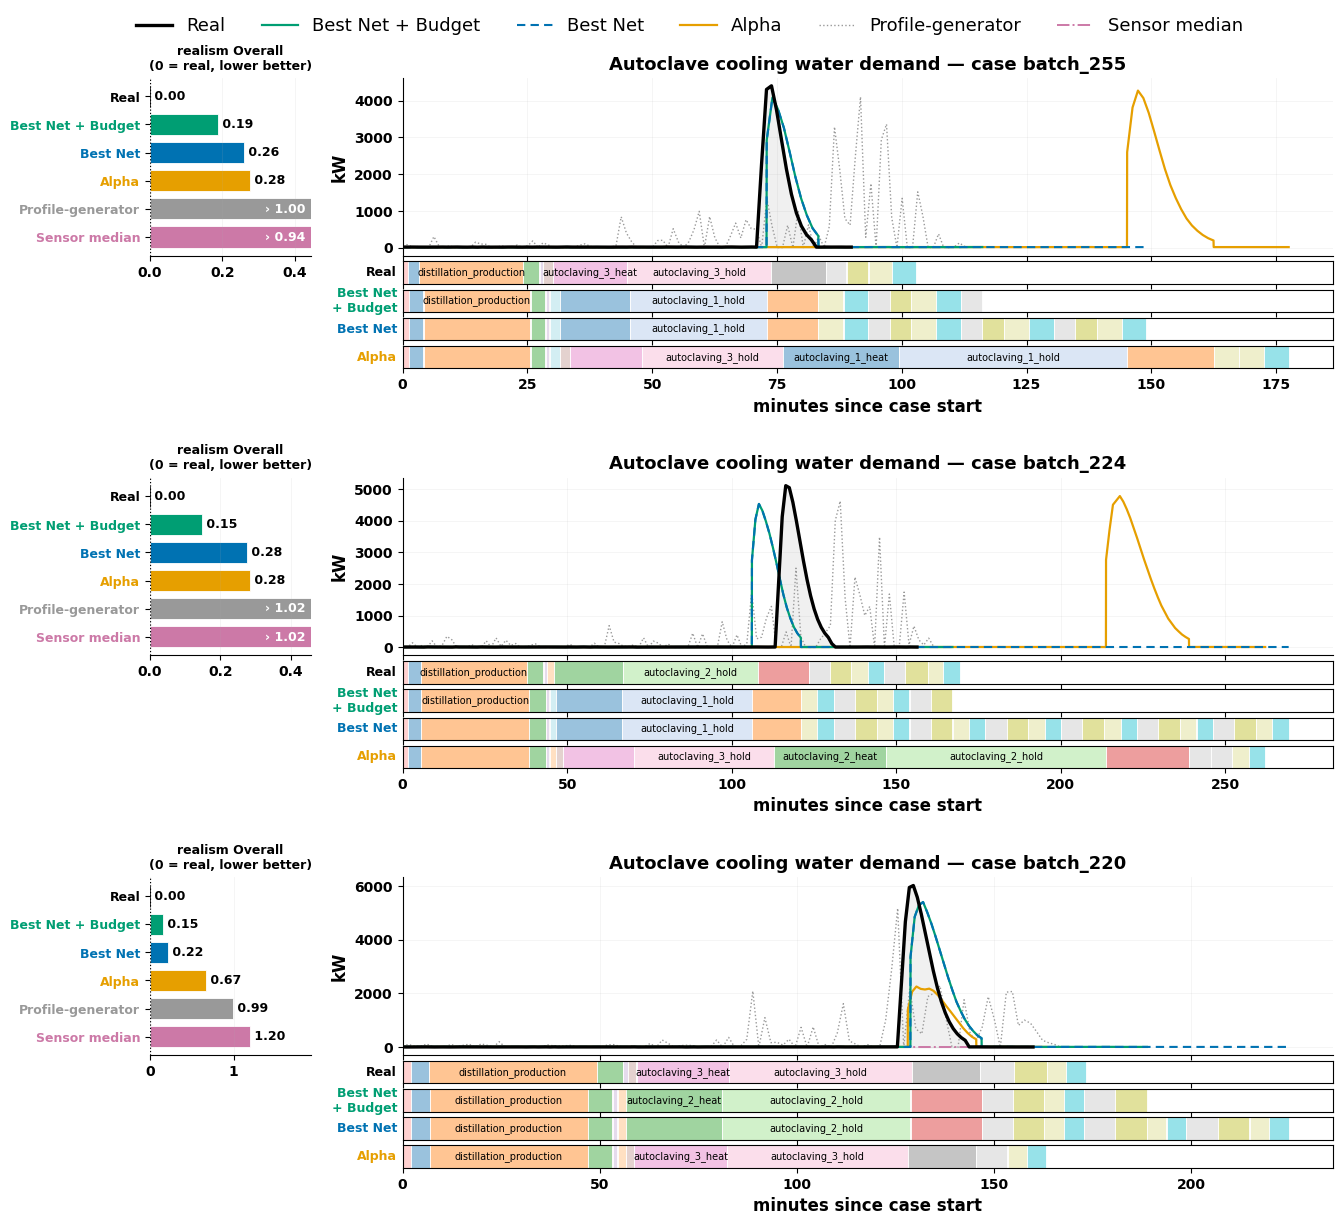

In [36]:
# -- One sensor, with the per-approach mean next to each curve -----------------
# The point of this figure: a scalar summary of a case (here the mean kW) can be
# almost identical across approaches while the curves behind those numbers are
# nothing alike -- which is exactly why the profiles, not the aggregates, are
# what has to be evaluated. Same helpers, styles and activity strips as the
# paired figures below, plus a mean bar panel on the LEFT of every curve.
import matplotlib.colors as mcolors

SINGLE_SENSOR = 'autoclave_cooling_water_demand_kW_energy_to_model'
SINGLE_TITLE  = 'Autoclave cooling water demand'
# >>> WHICH BATCHES ARE DRAWN <<<
# By default: exactly the CASES of the config cell above, in that order, one row
# each -- nothing is added. To draw other batches here WITHOUT touching the rest
# of the notebook, list them below instead. Every batch of this run is printed by
# this cell with its real length, so pick straight from that output; unknown
# names are reported and dropped.
#   SINGLE_CASES = ['batch_294', 'batch_217', 'batch_272', 'batch_293']
SINGLE_CASES   = None     # None = follow CASES
SINGLE_N_CASES = None     # None = draw every case named; or cap the rows, e.g. 4

# How washed-out the gantt strips under each curve are drawn: the activity
# colours are blended toward white by this fraction, hues and the activity ->
# colour mapping unchanged, so the strips read as a soft background band and the
# curves keep the visual weight. 0 = the saturated colours the other figures
# use, 1 = white. Only THIS figure is affected -- the shared colour map is
# restored after the rows are drawn.
STRIP_PASTEL = 0.55

def _pastel(c, amount=None):
    """Blend a colour toward white -- same hue, less weight."""
    a = STRIP_PASTEL if amount is None else amount
    r, g, b = mcolors.to_rgb(c)
    return (r + (1 - r) * a, g + (1 - g) * a, b + (1 - b) * a)

# Series drawn here, in legend/drawing order. Best Net uses the same net and the
# same curve predictor as Best Net + Budget, so the two curves are near-identical
# in shape (budgeting changes where a case ENDS, not the profile) -- Best Net
# is dashed and drawn on top so it stays visible where the two coincide.
# Sensor median is the flat baseline of the individual-profile results: one
# horizontal line at the sensor's median level (see the block below the sensor
# filter for where the value comes from).
SINGLE_SERIES = ['Real', 'Best Net + Budget', 'Best Net', 'Alpha',
                 'Profile-generator', 'Sensor median']

# What the bar panel on the left reports:
# 'realism' -- the Overall realism error of 04_results_individual_profile.ipynb:
#              the mean over Sum / Max / Mean / Std / Roughness of
#              |f(pred) - f(real)| / mean|f(real)|. 0 = perfect, lower is better,
#              so Real is 0 by construction and is drawn as the reference.
# 'mean'    -- time-weighted mean kW (the helper cell's _curve_mean, so this panel
#              and the mean panel of the other figures are the same number).
# 'median'  -- median kW on a 1-minute grid. The medians sit much closer together
#              than the means do (a short peak barely moves a median).
SINGLE_STAT   = 'realism'    # 'realism' | 'mean' | 'median'

SINGLE_PDF    = f'visuals/predicted_vs_real_autoclave_cooling_{SINGLE_STAT}_{PROCESS}.pdf'

# Every font size in this figure, in points -- scale the whole thing from here.
SINGLE_FS = {             'legend':      13,   # (no figure title -- the per-case titles carry it)
             'title':       13,   # per-case curve title
             'axis':        12,   # 'kW' and 'minutes since case start'
             'tick':        10,   # tick labels, both panels
             'panel_title':  9,   # header of the bar panel
             'bar':          9,   # bar value labels and approach names
             'strip_label':  9,   # the series name next to each gantt
             'strip':        7}   # activity names inside the gantt bars

# What the mean is taken over -- MEAN_OVER from the config cell:
#   'case'  -- the integral is divided by the FULL case span, so minutes an
#              approach does not cover count as 0 kW and predicting less earns
#              nothing.
#   'curve' -- each curve's own span.
# `_curve_mean` itself is the helper cell's, so this panel and the mean panel of
# the other figures compute the identical number.

# -- Overall realism, exactly as 04_results_individual_profile.ipynb defines it --
#   err_f = |f(pred) - f(real)| / mean|f(real)|   per curve, per feature
#   Overall = mean over the features below           -> 0 is perfect, lower better
# The scale is the sensor's typical real magnitude, so it is taken over ALL the
# run's cases for this sensor, not over the handful drawn here.
REALISM_METRICS = ('sum', 'max', 'mean', 'std', 'roughness')

def _curve_feature(v, name):
    v = np.asarray(v, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    if name == 'sum':       return float(np.sum(v))
    if name == 'max':       return float(np.max(v))
    if name == 'mean':      return float(np.mean(v))
    if name == 'std':       return float(np.std(v))
    if name == 'roughness': return float(np.abs(np.diff(v)).mean()) if v.size >= 2 else np.nan
    raise ValueError(name)


def _realism_scales(sub_sensor):
    """mean|f(real)| over every case of this sensor -- the normaliser."""
    _reals = sub_sensor[sub_sensor['series'] == 'Real']
    out = {}
    for f in REALISM_METRICS:
        _v = [_curve_feature(g['value'].to_numpy(), f)
              for _, g in _reals.sort_values('t_minutes').groupby('case_id')]
        _v = np.abs(np.array(_v, dtype=float))
        _s = float(np.nanmean(_v)) if np.isfinite(_v).any() else np.nan
        if np.isfinite(_s) and _s >= 1e-6:      # a feature the real curves lack
            out[f] = _s                          # carries no information
    return out


def _curve_realism(s, real_s, scales):
    """Overall realism error of one predicted curve against its own real curve."""
    p, r = s['value'].to_numpy(), real_s['value'].to_numpy()
    errs = []
    for f, scale in scales.items():
        fp, fr = _curve_feature(p, f), _curve_feature(r, f)
        if np.isfinite(fp) and np.isfinite(fr):
            errs.append(abs(fp - fr) / scale)
    return float(np.mean(errs)) if errs else np.nan


def _curve_median(s, case_span=None):
    """Median kW of one curve, on a 1-minute grid over the case span."""
    t, v = s['t_minutes'].to_numpy(), s['value'].to_numpy()
    if len(t) == 0:
        return 0.0
    if MEAN_OVER == 'case' and case_span:
        grid = np.arange(0.0, float(case_span) + 1.0)
        vals = np.interp(grid, t, v, left=0.0, right=0.0)   # uncovered minutes -> 0
        vals[(grid < t.min()) | (grid > t.max())] = 0.0
        return float(np.median(vals))
    return float(np.median(v))


def _draw_stat_panel(ax, sub, names):
    """Horizontal bar per approach, same order and colours as the curves."""
    # The span is the REAL case, not the longest prediction: a method that runs
    # far past the case must not stretch the grid everything else is padded onto
    # (that would zero-pad the real curve into a median of 0).
    _real_s = sub[sub['series'] == 'Real']
    _span = float(_real_s['t_minutes'].max() if not _real_s.empty else sub['t_minutes'].max())
    vals, cols, labels = [], [], []
    for name in names:
        s = sub[sub['series'] == name].sort_values('t_minutes')
        if s.empty:
            continue
        if SINGLE_STAT == 'realism':
            vals.append(0.0 if name == 'Real'          # the real curve IS the target
                        else _curve_realism(s, _real_s, _REALISM_SCALES))
        elif SINGLE_STAT == 'mean':
            vals.append(_curve_mean(s, _span))
        else:
            vals.append(_curve_median(s, _span))
        cols.append(_series_style[name]['color'])
        labels.append(name)
    ypos = list(range(len(vals)))
    # Real is drawn like the curve is -- black and outlined -- so the reference
    # bar is not lost among five bars that all end in the same place.
    _edge = ['black' if l == 'Real' else 'white' for l in labels]
    ax.barh(ypos, vals, color=cols, edgecolor=_edge, linewidth=0.6, height=0.75)
    _real = vals[labels.index('Real')] if 'Real' in labels else None
    if _real is not None:                      # reference line at the real median
        ax.axvline(_real, color='black', linewidth=0.9, linestyle=':', zorder=5)

    # Scale on the bars that are actually close to each other -- one approach far
    # off the real median (the stochastic generator is, by an order of magnitude)
    # would otherwise flatten the ones the figure is about. Off-scale bars are
    # clipped and marked with a caret, their value still written next to them.
    # Scaled on the median of the bars, not on Real -- Real itself can be small
    # on a case whose cooling window covers little of the case span.
    _center = float(np.median(vals)) if vals else 0.0
    _in_scale = [v for v in vals if v <= 3 * _center] or vals
    _xmax = (max(_in_scale) or 1) * 1.6
    _fmt = '{:,.2f}' if SINGLE_STAT == 'realism' else '{:,.1f}'
    for y, v in zip(ypos, vals):
        _off = v > _xmax
        _x = min(v, _xmax * 0.97)
        ax.text(_x, y, ('› ' if _off else ' ') + _fmt.format(v), va='center',
                ha='right' if _off else 'left', fontsize=SINGLE_FS['bar'], clip_on=False,
                fontweight='bold',
                color='white' if _off else 'black')   # off-scale: written on the bar
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=SINGLE_FS['bar'], fontweight='bold')
    for tick, col in zip(ax.get_yticklabels(), cols):
        tick.set_color(col)
    ax.invert_yaxis()
    ax.set_xlim(0, _xmax)
    ax.tick_params(axis='x', labelsize=SINGLE_FS['tick'])
    for _t in ax.get_xticklabels():
        _t.set_fontweight('bold')
    ax.locator_params(axis='x', nbins=3)       # narrow panel -- few ticks
    ax.set_title('realism Overall\n(0 = real, lower better)' if SINGLE_STAT == 'realism'
                 else f'{SINGLE_STAT} kW\n(over {MEAN_OVER})',
                 fontsize=SINGLE_FS['panel_title'], fontweight='bold')
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.grid(axis='x', alpha=0.15, linewidth=0.6)


_sub_sensor = df_curves[df_curves['sensor'] == SINGLE_SENSOR]
assert not _sub_sensor.empty, f'{SINGLE_SENSOR} not in this run'

# -- The 'Sensor median' baseline: a flat line at the sensor's median level ---
# The value is the pipeline's own baseline constant, read from the run's
# curve_eval_results.parquet: the 'Baseline' approach predicts exactly that
# constant, so the mean of its flat curve IS the sensor median (train-derived).
# Fallback if the run lacks the file/approach: median over every real value of
# this sensor in df_curves. The line is sampled on each REAL curve's own time
# grid, so the realism features (sum, roughness, ...) compare curves with the
# same number of samples -- exactly like the individual-profile baseline.
_series_style.setdefault('Sensor median',
                         dict(color='#CC79A7', linestyle='-.', linewidth=1.4, zorder=3))
_bl_val = None
try:
    _blf = pd.read_parquet(run_dir / 'curve_eval_results.parquet',
                           columns=['Approach', 'Process', 'Sensor', 'Split', 'mean_pred'])
    _blf = _blf[(_blf['Approach'] == 'Baseline') & (_blf['Process'] == PROCESS)
                & (_blf['Sensor'] == SINGLE_SENSOR) & (_blf['Split'] == 'TRAIN')]
    if not _blf.empty:
        _bl_val = float(_blf['mean_pred'].median())
        print(f'Sensor median baseline: {_bl_val:,.2f} kW  (pipeline Baseline approach, TRAIN)')
except (FileNotFoundError, KeyError):
    pass
if _bl_val is None:
    _bl_val = float(_sub_sensor.loc[_sub_sensor['series'] == 'Real', 'value'].median())
    print(f'Sensor median baseline: {_bl_val:,.2f} kW  '
          '(fallback: median of the real curves in this run)')

_bl_rows = [pd.DataFrame({'case_id': _cid, 'sensor': SINGLE_SENSOR,
                          'series': 'Sensor median',
                          't_minutes': _g['t_minutes'].to_numpy(),
                          'value': _bl_val})
            for _cid, _g in (_sub_sensor[_sub_sensor['series'] == 'Real']
                             .sort_values('t_minutes').groupby('case_id'))]
if _bl_rows:
    _sub_sensor = pd.concat([_sub_sensor] + _bl_rows, ignore_index=True)

_REALISM_SCALES = _realism_scales(_sub_sensor)     # over ALL cases of the sensor
if SINGLE_STAT == 'realism':
    print('Realism scales (mean|f(real)| over '
          f'{_sub_sensor[_sub_sensor["series"] == "Real"]["case_id"].nunique()} cases): '
          + '  '.join(f'{k}={v:,.1f}' for k, v in _REALISM_SCALES.items()))

# Every batch of this run with its real length -- pick from this output for
# SINGLE_CASES above or CASES in the config cell. Recomputed here so the list
# is always current, whatever ran before.
_len = (df_curves[df_curves['series'] == 'Real']
        .groupby('case_id')['t_minutes'].max().sort_values())
print(f'Available batches ({len(_len)}), shortest first:')
print('  ' + '\n  '.join(f'{c}  ({m:.0f} min)' for c, m in _len.items()))

# Cases: exactly SINGLE_CASES if set, otherwise exactly CASES, in that order.
# CASES is read HERE, at draw time -- edit either list and re-run just this
# cell; no other cell needs to run again. Nothing is ever added on top -- to
# draw more rows, name more batches.
_wanted = (list(SINGLE_CASES) if SINGLE_CASES
           else list(CASES) if CASES else list(example_cases))
_single_cases = [c for c in _wanted if c in set(_len.index)]
_unknown = [c for c in _wanted if c not in set(_len.index)]
if _unknown:
    print(f'!! not in this run, dropped: {_unknown}')
if SINGLE_N_CASES:                       # optional cap, None = draw them all
    _single_cases = _single_cases[:SINGLE_N_CASES]
print(f'Drawing {len(_single_cases)} cases '
      f'(from {"SINGLE_CASES" if SINGLE_CASES else "CASES"}): '
      + ', '.join(f'{c} ({_len[c]:.0f} min)' for c in _single_cases))
_strips = ([('Real', df_real_log, 'black')]
           + [(m, sim_logs[m], _series_style[m]['color'])
              for m in SINGLE_SERIES if m != 'Real' and m in sim_logs])

# Rows: one block per case (curve + one strip per log), thin spacer in between.
_height_ratios, _row_start = [], []
for i, _ in enumerate(_single_cases):
    _row_start.append(len(_height_ratios))
    _height_ratios += [4] + [0.5] * len(_strips)
    if i < len(_single_cases) - 1:
        _height_ratios.append(2.2)

# Columns: median panel | gutter | curve. The median panel is a handful of short
# bars -- it stays narrow so the curves and the activity strips get the width.
_width_ratios = [1.9, 0.55, 11.0]

fig = plt.figure(figsize=(13.0, (2.9 + 0.3 * len(_strips)) * len(_single_cases)))
_H = fig.get_figheight()
# Placed explicitly rather than via tight_layout: with this many rows the
# gridspec is not tight_layout-compatible (the strips share x with the curve),
# and it left a large empty band under the legend.
gs = fig.add_gridspec(len(_height_ratios), len(_width_ratios),
                      height_ratios=_height_ratios, width_ratios=_width_ratios,
                      hspace=0.1, wspace=0.06,
                      left=0.085, right=0.995, bottom=0.45 / _H, top=1 - 0.95 / _H)

_present = [s for s in SINGLE_SERIES if s in set(_sub_sensor['series'])]
handles = [Line2D([0], [0], label=s, **_series_style[s]) for s in _present]

# The strips are drawn from the shared activity -> colour map; it is swapped for
# a pastel copy for the length of this figure only and put back afterwards, so
# the other figures keep the saturated colours and re-running this cell cannot
# fade the map a second time.
_saved_activity_colors = dict(_activity_color_map)
try:
    for i, cid in enumerate(_single_cases):
        r0  = _row_start[i]
        sub = _sub_sensor[_sub_sensor['case_id'] == cid]

        # Stat panel spans the curve row only, so it lines up with the curve axes.
        ax_med   = fig.add_subplot(gs[r0, 0])
        ax_curve = fig.add_subplot(gs[r0, 2])
        ax_strips = [fig.add_subplot(gs[r0 + 1 + k, 2], sharex=ax_curve)
                     for k in range(len(_strips))]

        if sub.empty:
            ax_curve.set_title(f'{SINGLE_TITLE} — case {cid} — no data',
                               fontsize=SINGLE_FS['title'], fontweight='bold')
            ax_med.axis('off')
        else:
            _draw_stat_panel(ax_med, sub, SINGLE_SERIES)
            _draw_series(ax_curve, sub, SINGLE_SERIES)
            ax_curve.set_title(f'{SINGLE_TITLE} — case {cid}',
                               fontsize=SINGLE_FS['title'], fontweight='bold')
        ax_curve.set_ylabel('kW', fontsize=SINGLE_FS['axis'], fontweight='bold')
        ax_curve.tick_params(labelsize=SINGLE_FS['tick'])
        for _t in ax_curve.get_yticklabels():
            _t.set_fontweight('bold')
        _clean(ax_curve)
        plt.setp(ax_curve.get_xticklabels(), visible=False)

        for k, ((_lbl, _log, _col), ax_s) in enumerate(zip(_strips, ax_strips)):
            # Display-only: the logs spell the node 'Destillation' -- rename it in
            # the strip labels of THIS figure, keeping the colour that spelling has
            # in the other figures. The logs themselves are untouched.
            _tl = _activity_timeline(_log, cid)
            if _tl is not None and not _tl.empty:
                for _a in _tl['activity'].astype(str).unique():
                    if 'estillation' in _a:
                        _activity_color_map.setdefault(
                            _a.replace('Destillation', 'Distillation')
                              .replace('destillation', 'distillation'),
                            _color_for_activity(_a))
                _tl = _tl.assign(activity=_tl['activity'].astype(str)
                                 .str.replace('Destillation', 'Distillation', regex=False)
                                 .str.replace('destillation', 'distillation', regex=False))
                # Pastel the colours of exactly the activities this strip shows.
                # Resolved against the ORIGINAL map, so an activity that appears
                # on several rows is lightened once, by the same amount.
                for _a in _tl['activity'].astype(str).unique():
                    _base = _saved_activity_colors.get(_a)
                    if _base is None:
                        _base = _color_for_activity(_a)      # first sighting
                        _saved_activity_colors[_a] = _base
                    _activity_color_map[_a] = _pastel(_base)
            _draw_activity_strip(ax_s, _tl, fontsize=SINGLE_FS['strip'])
            ax_s.set_ylabel(_lbl.replace(' + ', '\n+ '), rotation=0, ha='right',
                            va='center', fontsize=SINGLE_FS['strip_label'], color=_col,
                            fontweight='bold')
            ax_s.tick_params(labelsize=SINGLE_FS['tick'])
            if k < len(_strips) - 1:
                plt.setp(ax_s.get_xticklabels(), visible=False)
            else:
                ax_s.set_xlabel('minutes since case start', fontsize=SINGLE_FS['axis'],
                                fontweight='bold')
                for _t in ax_s.get_xticklabels():
                    _t.set_fontweight('bold')
finally:
    _activity_color_map.clear()                 # hand the saturated map back
    _activity_color_map.update(_saved_activity_colors)

if handles:
    fig.legend(handles=handles, labels=[h.get_label() for h in handles],
               loc='upper center', bbox_to_anchor=(0.5, 1 - 0.18 / _H),
               ncol=len(handles), fontsize=SINGLE_FS['legend'], frameon=False)
Path(SINGLE_PDF).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(SINGLE_PDF, format='pdf', bbox_inches='tight', dpi=300, facecolor='white')
print(f'Saved visual to: {SINGLE_PDF}')
plt.show()


## 4. Process model and energy profiles — real (a) vs simulated (b)

Left to right a block reads as a zoom: material flow, the focus machine's activity net, and the
energy profile of each of its activities. (a) is built from the gold log and the real curves of the
run's test split, (b) from the same run's simulated log and predicted curves only.


In [12]:
# ── Config ───────────────────────────────────────────────────────────────────
RUN             = 'experiment_1000'   # dir under ../results: full name or any substring (latest match)
DATA_EXPERIMENT = '1'                # gold data experiment that run was fed with
PROCESS         = 'process_1'
SPLIT           = 'test'             # 'test' | 'train' | 'all'  — which cases the curves come from
FOCUS_OBJECT    = 'autoclaving_2'    # the machine the machine-activity layer zooms into

# Curve panels given as (phase, sensor).  The activity name is built as
# f'{FOCUS_OBJECT}_{phase}', so only the PHASE is spelled here.  Writing the whole activity by
# hand is how you end up asking for 'autoclaving_1' instead of 'autoclaving_1_heat' -- that
# matches no activity, yields 0 curves, and the panel is silently dropped.
# Set PANEL_PHASES = None to auto-pick the dominant sensor of every FOCUS_OBJECT activity.
# Set a phase's sensor to 'autoclave_temperature_C' to show the vessel temperature instead of a
# demand channel -- it is NOT a recorded sensor but the physical autoclave model re-solved at that
# occurrence's own duration and volume (see cell 4).
PANEL_PHASES = [
    ('heat', 'autoclave_steam_demand_kW_energy_to_model'),
    ('hold', 'autoclave_steam_demand_kW_energy_to_model'),
    ('cool', 'autoclave_cooling_water_demand_kW_energy_to_model'),
]
PANELS = None if PANEL_PHASES is None else [(f'{FOCUS_OBJECT}_{ph}', s) for ph, s in PANEL_PHASES]

# ── Where the curves come from ───────────────────────────────────────────────
CURVE_SOURCE = 'real_expanded'   # 'real_expanded' | 'run_real' | 'run_predicted'

# Only used by 'run_real' / 'run_predicted':
SIM_SCOPE    = 'complete'        # 'complete' → complete_curve_eval_results/<process>/<SIM_MODE>/
                                 # 'schedule' → schedule_profile_eval_results/<process>/
SIM_MODE     = 'petri_net_budget_ml_plus_per_act'      # net + duration-model directory
                                 # best mode for process_1 by the run's own test_overall_error
                                 # (0.1136 vs 0.1182 for petri_net_heuristic_ml_plus_per_act)
SIM_APPROACH = 'ml_step_dtw_smooth'        # curve approach; '' → predicted_curves.parquet
                                 # NB approaches are per-run: 976 saved exemplar /
                                 # median_activity_sensor / ml_external / ml_rawspace,
                                 # 988 saved ml_step_dtw only (same test split either way)
SIM_SERIES   = None              # None → 'real' for run_real, 'predicted' for run_predicted.
                                 # 'schedule' scope also has: schedule, stochastic, bootstrap,
                                 # best, best_duration_corrected, best_budget
SIM_LOG      = 'auto'            # which log gives the activity windows:
                                 # 'auto' → real test log for real/schedule/stochastic/bootstrap,
                                 #          predicted_logs/<process>_<SIM_MODE>.parquet otherwise
                                 # 'real' | 'sim' to force it

# ── Plotting ─────────────────────────────────────────────────────────────────
MAX_CURVES   = 60                # occurrences drawn per panel (None = all)
NET_DPI      = 200               # graphviz render resolution for the two nets
NET_MARGIN   = 0.1               # graphviz page margin, inches (used to place the arrows)
OUT_DIR      = 'visuals/process_and_profiles'
SAVE         = True    # save the FINAL combined figure
SAVE_NETS    = False   # write the raw graphviz nets as separate PDFs
SHOW_INTERMEDIATE = False   # draw the net previews + the two standalone figures

In [13]:
import ast
import re
import sys
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
from IPython.display import Image, display

import pm4py
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_vis

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 130,
})

REPO    = next(d for d in [Path.cwd(), *Path.cwd().parents]
               if (d / 'results').is_dir() and (d / 'data').is_dir())   # repo root, from anywhere
RESULTS = REPO / 'results'
GOLD    = REPO / 'data' / 'gold' / f'experiment_{DATA_EXPERIMENT}' / PROCESS / 'datasets'
OUT     = Path(OUT_DIR)
if SAVE:
    OUT.mkdir(parents=True, exist_ok=True)

_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]

df_event_log = pd.read_parquet(GOLD / 'df_event_log.parquet')
df_expanded  = pd.read_parquet(GOLD / 'df_expanded.parquet')

SENSOR_COLS = [c for c in df_expanded.columns if c.endswith('_energy_to_model')]

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'gold  : {GOLD.relative_to(REPO)}')
print(f'log   : {len(df_event_log)} events, {df_event_log["case_id"].nunique()} cases, '
      f'{df_event_log["activity"].nunique()} activities')
print(f'energy: {len(df_expanded)} rows, {len(SENSOR_COLS)} sensors')

run   : experiment_1000_20260729_201444   (latest match for 'experiment_1000')
gold  : data/gold/experiment_1/process_1/datasets
log   : 5621 events, 300 cases, 25 activities
energy: 36268 rows, 6 sensors


In [14]:
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 210 / 90 cases
SPLIT='test' → 90 cases used below


In [15]:
el = (df_event_log[df_event_log['case_id'].isin(cases)]
      .sort_values(['case_id', 'timestamp_start'])
      .copy())

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} does not appear in this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

# activities of the focus machine, in process order (mean position within its own trace)
_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


material flow  : 635 handovers, nodes = ['Warehousing', 'Individual_packaging', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_3', 'autoclaving_1']
machine layer  : 184 events on autoclaving_2 (40 cases)
  activities in process order: ['autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool']


activity,autoclaving_2_cool,autoclaving_2_heat,autoclaving_2_hold,autoclaving_2_prepare
events,46,46,46,46


In [16]:
def load_net_image(png):
    """Read a graphviz PNG and flatten it onto white -- its page margin is transparent,
    which otherwise shows up as a faint rectangle around the net."""
    im = mpimg.imread(png)
    if im.ndim == 3 and im.shape[2] == 4:
        rgb, alpha = im[..., :3], im[..., 3:4]
        im = rgb * alpha + (1.0 - alpha)
    return im


def _to_pm4py(df, activity_col):
    d = df.rename(columns={'case_id': 'case:concept:name',
                           activity_col: 'concept:name',
                           'timestamp_start': 'time:timestamp'})
    d = d[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    d['time:timestamp'] = pd.to_datetime(d['time:timestamp'])
    return pm4py.convert_to_event_log(d)


def heuristic_net(df, activity_col, pdf_name=None, **heu_kwargs):
    """Mine + render a heuristics net.  Returns (png_path, gviz) — the graphviz object is
    kept so cell 7b can read the node coordinates back out of it."""
    log = _to_pm4py(df, activity_col)
    net = heuristics_miner.apply_heu(log, parameters=heu_kwargs or None)
    gviz = hn_vis.apply(net)
    try:                                  # sharper rendering + a known margin
        gviz.graph_attr['dpi'] = str(NET_DPI)
        gviz.graph_attr['margin'] = str(NET_MARGIN)
    except Exception:
        pass
    png = tempfile.NamedTemporaryFile(suffix='.png', delete=False).name
    hn_vis.save(gviz, png)
    if SAVE_NETS and pdf_name:
        # hn_vis.save() writes PNG bytes whatever the extension -- render vector via graphviz
        gviz.render(str(OUT / Path(pdf_name).stem), format='pdf', cleanup=True)
        print(f'saved {OUT / pdf_name}')
    return png, gviz


png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_material))


# ── Pinned layout: draw the simulated net where the real one put its nodes ────
# The two nets are mined from different logs, so pm4py hands graphviz the same
# activities in a different order and dot's crossing minimiser lands on a different
# left-to-right arrangement -- the halves then LOOK like different processes when the
# discovered structure is identical (same nodes, same edges; only the frequencies on
# them differ). Laying the second net out at the first one's coordinates removes that
# false signal: anything that still looks different between the halves IS different.
import graphviz, re

# pm4py quotes the uuid node ids but writes the start/end markers bare (`start_0 [...]`),
# and -n2 fails outright if ANY node lacks a position -- so both forms must match.
_NODE_LINE = re.compile(r'^\s*(?P<id>"[^"]+"|[A-Za-z_]\w*)\s*\[(?P<attrs>.*)\]\s*$')


class _PinnedGraph:
    """A graphviz graph whose layout is fixed: every pipe() goes through neato -n2.

    Needed because pinning is a RENDER-time flag, not a graph attribute. Without it
    neato treats `pos` as a starting hint and relaxes the layout anyway, and
    net_node_positions() -- which pipes 'plain' to place the arrows -- would report
    coordinates the picture does not use."""

    def __init__(self, graph):
        self._g = graph
        self.graph_attr = graph.graph_attr

    def pipe(self, *args, **kwargs):
        kwargs.setdefault('neato_no_op', 2)
        return self._g.pipe(*args, **kwargs)


def _plain_positions(gviz):
    """label (without its ' (count)' suffix) -> (x, y) in graphviz inches."""
    txt = gviz.pipe(format='plain').decode('utf-8', 'replace')
    out = {}
    for line in txt.splitlines():
        try:
            parts = shlex.split(line)
        except ValueError:
            continue
        if parts and parts[0] == 'node' and len(parts) >= 7:
            out[parts[6].split(' (')[0]] = (float(parts[2]), float(parts[3]))
    return out


def pin_net_like(png, gviz, reference_gviz, pdf_name=None):
    """Re-render `gviz` with every node fixed where `reference_gviz` placed it.

    Node identity is the label minus its frequency suffix, since the counts differ
    between the two logs. neato with pos+pin keeps the nodes and routes the edges
    around them. Returns (png, gviz) like heuristic_net; if the reference has no
    position for some node -- a genuinely different net -- nothing is pinned and the
    net keeps its own layout, because forcing a partial one would be a lie."""
    try:
        pos = _plain_positions(reference_gviz)
    except Exception as exc:
        print(f'! reference layout unavailable ({exc}) — simulated net keeps its own')
        return png, gviz

    g = graphviz.Digraph(engine='neato', strict=True)
    g.graph_attr.update(gviz.graph_attr)
    g.graph_attr.update(splines='true', overlap='true')
    missing = []
    for line in gviz.body:
        m = _NODE_LINE.match(line)
        if m and '->' not in line:
            lab = re.search(r'label="([^"]*)"', m.group('attrs'))
            key = lab.group(1).split(' (')[0] if lab else None
            if key not in pos:
                missing.append(key)
            else:
                x, y = pos[key]
                line = f'{line.rstrip()[:-1]} pos="{x * 72:.2f},{y * 72:.2f}" pin=true]'
        g.body.append(line)
    if missing:
        print(f'! not in the reference net: {missing} — simulated net keeps its own layout')
        return png, gviz

    pinned = _PinnedGraph(g)
    out_png = tempfile.NamedTemporaryFile(suffix='.png', delete=False).name
    with open(out_png, 'wb') as fh:
        fh.write(pinned.pipe(format='png'))
    if SAVE_NETS and pdf_name:
        with open(OUT / Path(pdf_name).with_suffix('.pdf').name, 'wb') as fh:
            fh.write(pinned.pipe(format='pdf'))
        print(f'saved {OUT / pdf_name} (pinned to the real net)')
    return out_png, pinned


In [17]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_machine))


In [18]:
# Tolerance when slicing a run curve by an activity window, minutes.  Keep it at 0: back-to-back
# activities are only seconds apart, so any slack pulls the NEXT activity's first sample into the
# curve -- e.g. a hold curve flat at 22 kW ending on one 4007 kW sample of the following heat.
_EPS_MIN = 0.0
_curve_cache = {}


def curves_real_expanded(activity, sensor):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the occurrence started."""
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))].sort_values('datetime_energy')
    out = []
    for _, g in sub.groupby(['case_id_log', 'timestamp_start_log'], sort=True):
        v = g[sensor].to_numpy(dtype=float)
        t = (g['datetime_energy'] - g['datetime_energy'].iloc[0]).dt.total_seconds().to_numpy() / 60
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


def _run_curve_path():
    if SIM_SCOPE == 'complete':
        d = run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE
    else:
        d = run_dir / 'schedule_profile_eval_results' / PROCESS
    if not d.exists():
        _runs_with_curves = sorted({p.relative_to(RESULTS).parts[0]
                                    for p in RESULTS.glob('*/**/predicted_curves*.parquet')})
        raise AssertionError(f'{d} does not exist — this run saved no curves for that scope/mode.\n'
                             f'Runs that did: {_runs_with_curves}')
    for name in ([f'predicted_curves_{SIM_APPROACH}.parquet'] if SIM_APPROACH else []) + ['predicted_curves.parquet']:
        if (d / name).exists():
            return d / name
    raise AssertionError(f'no predicted_curves file for SIM_APPROACH={SIM_APPROACH!r} in {d}.\n'
                         f'available: {sorted(p.name for p in d.glob("predicted_curves*.parquet"))}')


def _run_curves_df():
    if 'curves' not in _curve_cache:
        p = _run_curve_path()
        _curve_cache['curves'] = pd.read_parquet(p)
        print(f'curves from {p.relative_to(run_dir)}  '
              f'| series: {sorted(_curve_cache["curves"]["series"].unique())}')
    return _curve_cache['curves']


def _window_log(series):
    use_real = (SIM_LOG == 'real') or (SIM_LOG == 'auto' and
                                       series in ('real', 'schedule', 'stochastic', 'bootstrap'))
    p = (run_dir / 'predicted_logs' /
         (f'{PROCESS}_test_set.parquet' if use_real else f'{PROCESS}_{SIM_MODE}.parquet'))
    assert p.exists(), f'{p} missing — cannot place activity windows for series {series!r}'
    key = ('log', p.name)
    if key not in _curve_cache:
        log = pd.read_parquet(p)
        log['timestamp_start'] = pd.to_datetime(log['timestamp_start'])
        log['timestamp_end']   = pd.to_datetime(log['timestamp_end'])
        _curve_cache[key] = log
        print(f'windows from predicted_logs/{p.name}')
    return _curve_cache[key]


def curves_from_run(activity, sensor, series):
    """Returns a list of (t_minutes, value) pairs, t_minutes elapsed since the activity started."""
    dfc = _run_curves_df()
    assert series in set(dfc['series']), \
        f'series {series!r} not in file (have {sorted(dfc["series"].unique())})'
    dfc = dfc[(dfc['sensor'] == sensor) & (dfc['series'] == series)]
    if dfc.empty:
        return []
    by_case = {c: g.sort_values('t_minutes') for c, g in dfc.groupby('case_id')}

    log = _window_log(series)
    log = log[log['case_id'].isin(cases)]
    case_t0 = log.groupby('case_id')['timestamp_start'].min()

    out = []
    occ = log[log['activity'] == activity].sort_values(['case_id', 'timestamp_start'])
    for _, r in occ.iterrows():
        g = by_case.get(r['case_id'])
        if g is None:
            continue
        t0 = case_t0[r['case_id']]
        a = (r['timestamp_start'] - t0).total_seconds() / 60
        b = (r['timestamp_end']   - t0).total_seconds() / 60
        sel = g.loc[g['t_minutes'].between(a - _EPS_MIN, b + _EPS_MIN)]
        v = sel['value'].to_numpy(dtype=float)
        t = sel['t_minutes'].to_numpy(dtype=float) - a
        mask = np.isfinite(v)
        v, t = v[mask], t[mask]
        if len(v) > 2:
            out.append((t, v))
    return out


# ── Vessel temperature — RECONSTRUCTED, not a recorded sensor ────────────────
# There is no temperature channel in this data.  The gold df_expanded and the run's curve files
# carry demand channels only (autoclave steam / cooling water, distillation steam / cooling,
# bottling, packaging, water supply) plus the exogenous weather columns ef_temperature_2m /
# ef_relative_humidity_2m -- and that ef_ temperature is outside air, not the vessel.
# The simulator DOES solve the vessel temperature: autoclave_function.sterilization_profile
# returns a 'temp' column, but generate_process_1.build_expanded writes only its Q, so the
# temperature was never persisted.  Replaying the generator to recover it does not work either --
# the current code no longer reproduces the gold log (different event structure and autoclave
# durations), so the RNG stream behind the recorded curves cannot be replayed.
#
# What happens instead: the SAME physical model is re-solved per occurrence, driven by that
# occurrence's own recorded numbers -- the cycle's total heat+hold+cool duration and its volume_L
# (which scales the thermal mass exactly as in the generator), at the ambient the generator solves
# the physics at.  Every other parameter stays at the generator's default, so no per-cycle
# randomisation is invented.  The reconstruction is faithful in the way that matters here: the
# model's own phase split reproduces the recorded phase durations (recorded heat 12.4 min ->
# reconstructed 12.4 min, etc.), so each curve spans the real occurrence's time.
# It is still a model output rather than a measurement, and the panel title says so.
TEMP_SENSOR = 'autoclave_temperature_C'

_STERI_PARAMS = ('m_dot_steam', 'm_dot_cool', 'A_U', 'T_steri', 'T_final', 'm_cp')


def _volume_of(attrs):
    """volume_L out of object_attributes — a dict in some logs, its repr in others."""
    if isinstance(attrs, str):
        attrs = ast.literal_eval(attrs)
    return float(attrs['volume_L'])


def _autoclave_cycles(log, machine):
    """The heat/hold/cool rows of each cycle `machine` ran, one DataFrame per cycle.

    The gold log labels cycles itself (autoclave_cycle_id); the simulated logs do not, so there a
    cycle is started by every 'heat' event of that machine within a case."""
    obj_col = 'resource_id' if 'resource_id' in log.columns else 'object'
    sub = log[(log[obj_col] == machine)
              & log['activity'].str.endswith(('_heat', '_hold', '_cool'))].copy()
    sub = sub[sub['case_id'].isin(cases)].sort_values(['case_id', 'timestamp_start'])
    if sub.empty:
        return []
    if 'autoclave_cycle_id' in sub.columns and sub['autoclave_cycle_id'].notna().all():
        keys = ['autoclave_cycle_id']
    else:
        sub['_cycle'] = sub.groupby('case_id')['activity'].transform(
            lambda s: s.str.endswith('_heat').cumsum())
        keys = ['case_id', '_cycle']
    return [g.sort_values('timestamp_start') for _, g in sub.groupby(keys, sort=True)]


def curves_temperature(activity):
    """Reconstructed vessel temperature (minutes, °C) for every occurrence of `activity`."""
    # imported here, not at cell level: the notebook must not need the simulator (or CoolProp)
    # unless a panel actually asks for the temperature.
    sys.path.insert(0, str(REPO / 'src' / 'simulation_process'))
    from autoclave_function import sterilization_profile
    import generate_process_1 as _gen

    machine, phase = activity.rsplit('_', 1)
    if CURVE_SOURCE == 'real_expanded':
        log = df_event_log                     # gold log — carries autoclave_cycle_id
    else:
        log = _window_log(SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted'))

    out = []
    for g in _autoclave_cycles(log, machine):
        if not g['activity'].str.endswith(f'_{phase}').any():
            continue
        t_ges = (g['timestamp_end'].max() - g['timestamp_start'].min()).total_seconds()
        if t_ges <= 0:
            continue
        p = dict(_gen.AUTOCLAVE_PARAM_DEFAULTS)
        p['m_cp'] *= _gen._load_factor(_volume_of(g['object_attributes'].iloc[0]))
        p['T_final'] = min(p['T_final'], p['T_steri'] - 20.0)      # stay physically valid
        prof = sterilization_profile(
            t_ges=int(round(t_ges)),
            T_amb=_gen.physics_ambient_c(g['timestamp_start'].min()) + 273.15,
            visual=False, **{k: p[k] for k in _STERI_PARAMS})
        seg = prof[prof['type'] == phase]
        if len(seg) > 2:
            t = (seg['time'].to_numpy(dtype=float) - float(seg['time'].iloc[0])) / 60
            out.append((t, seg['temp'].to_numpy(dtype=float)))
    return out


def panel_meta(sensor):
    """(y-axis label, panel title) for a sensor — the temperature panel is not in kW."""
    if sensor == TEMP_SENSOR:
        return '°C (reconstructed)', 'autoclave temperature'
    return 'kW', sensor.replace('_energy_to_model', '').replace('_energy', '')


def get_curves(activity, sensor):
    if sensor == TEMP_SENSOR:
        return curves_temperature(activity)
    if CURVE_SOURCE == 'real_expanded':
        return curves_real_expanded(activity, sensor)
    series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    return curves_from_run(activity, sensor, series)


# label that ends up in titles and file names
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')

CURVE_SOURCE='real_expanded' → real (gold expanded)


In [19]:
def dominant_sensor(activity):
    sub = df_expanded[(df_expanded['activity_log'] == activity)
                      & (df_expanded['case_id_log'].isin(cases))]
    if sub.empty:
        return None
    peaks = {c: float(sub[c].max()) for c in SENSOR_COLS}
    best = max(peaks, key=peaks.get)
    return best if peaks[best] > 0 else None


if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')

_bad = [a for a, _ in panels if a not in MACHINE_ACTIVITIES]
if _bad:
    print(f'!! these panels name activities {FOCUS_OBJECT} does not have: {_bad}'
          f'\n   available: {MACHINE_ACTIVITIES}')


  autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model


In [20]:
def draw_panel(ax, activity, sensor, curves, n_total, fs=1.0, ylabel='kW', title=None):
    """One profile panel.  The y unit and the title come from panel_meta(sensor)."""
    for t, v in curves:
        ax.plot(t, v, color='blue', alpha=0.15, lw=0.9)
    ax.set_title(title if title is not None else panel_meta(sensor)[1], fontsize=13 * fs)
    ax.set_xlabel('Time (min)', fontsize=12 * fs)
    ax.set_ylabel(ylabel, fontsize=12 * fs)
    ax.tick_params(labelsize=10.5 * fs)
    ax.text(0.99, 0.02, f'n={len(curves)}' + ('' if len(curves) == n_total else f' of {n_total}'),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=10 * fs, color='0.35')


def build_panel_data(panels):
    """(activity, sensor) -> curves + the panel's y unit and title, for draw_block."""
    out = {}
    for activity, sensor in panels:
        curves = get_curves(activity, sensor)
        if len(curves) < 2:
            print(f'!! {activity} / {sensor}: only {len(curves)} curve(s) — skipped')
            continue
        n_total = len(curves)
        used = curves[:MAX_CURVES] if MAX_CURVES else curves
        ylabel, title = panel_meta(sensor)
        out[(activity, sensor)] = dict(curves=used, n_total=n_total, ylabel=ylabel, title=title)
        print(f'{activity:<28} {sensor:<45} n={len(used)}'
              + ('' if len(used) == n_total else f' of {n_total}'))
    return out


panel_data = build_panel_data(panels)

autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model     n=46
autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model     n=46
autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model n=46


In [21]:
# ── Layout ───────────────────────────────────────────────────────────────────
PAPER_W, PAPER_H = 15.0, 9.0   # single-block figure size, inches
PROCESS_FRAC   = 0.58    # share of a block's width available to (material net + machine net)
NET_GAP        = 0.02    # gap between the two nets
PAPER_GAP      = 0.045   # gap profile block -> process block.  The profiles are the LEFT half
                         # now, so this gap only has to carry the arrows -- keep it just wide
                         # enough that the two frames read as two boxes
YLAB_PAD       = 0.055   # left margin of the profile block; holds the panels' y-axis labels,
                         # which matplotlib draws to the LEFT of the panel
PANEL_W_SCALE  = 1.00    # panels fill the width left over by the process block
PANEL_H_SCALE  = 0.88
MH_MAX         = 0.800   # net height cap (leaves room for titles + caption)
MX             = 0.012   # left margin of a block's content, in block fractions
PAPER_BOXES    = True
ARROW_COLOR    = '#c00000'
BOX_COLORS     = ('#e8a33d', '#7fb3d5')   # process block, profile block
CAPTION_REAL   = '(a) real test set process and energy profiles'
CAPTION_SIM    = '(b) simulated process and energy profiles'

import shlex
from matplotlib.patches import ConnectionPatch, FancyBboxPatch
from matplotlib.ticker import MaxNLocator


def net_node_positions(gviz, png):
    """activity -> (x, y, w, h) of its node box, as fractions of the rendered image.

    graphviz's 'plain' output gives the layout in inches without the page margins, so the
    padding is recovered from the PNG's own size -- no assumption about graphviz defaults."""
    try:
        txt = gviz.pipe(format='plain').decode('utf-8', 'replace')
    except Exception as exc:
        print(f'! graphviz layout unavailable ({exc}) — arrows anchor to the box edge')
        return {}
    rows = []
    W0 = H0 = None
    for line in txt.splitlines():
        try:
            parts = shlex.split(line)
        except ValueError:
            continue
        if not parts:
            continue
        if parts[0] == 'graph' and len(parts) >= 4:
            W0, H0 = float(parts[2]), float(parts[3])
        elif parts[0] == 'node' and len(parts) >= 7:
            rows.append([float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5]), parts[6]])
    if W0 is None:
        return {}
    _h_px, _w_px = mpimg.imread(png).shape[:2]
    dpi = float(gviz.graph_attr.get('dpi', 96) or 96)
    pad_x, pad_y = (_w_px / dpi - W0) / 2, (_h_px / dpi - H0) / 2      # margins, inches
    W, H = W0 + 2 * pad_x, H0 + 2 * pad_y
    # graphviz 'plain' reports the node CENTRE (x, y) and its full width/height -- convert to the
    # top-left corner, otherwise every anchor sits half a box off and the arrows miss the node.
    return {label.split(' (')[0].strip():
            ((x - w / 2 + pad_x) / W, 1 - (y + h / 2 + pad_y) / H, w / W, h / H)
            for x, y, w, h, label in rows}


def make_block(png_material, gviz_material, png_machine, gviz_machine, panel_data, focus,
               net_title='Material flow activities'):
    """Bundle everything one figure-block needs, so a block survives being recomputed later.

    `png_machine=None` builds a SINGLE-net block: the left side holds only the material/process
    net and the profile arrows start at that net's own activity boxes.  Section 11 needs this --
    process_2 has one modelled object, so there is no second layer to zoom into."""
    return dict(png_material=png_material, gviz_material=gviz_material,
                png_machine=png_machine, gviz_machine=gviz_machine,
                panel_data=dict(panel_data), focus=focus, net_title=net_title)


def _net_inches(png):
    """The net's true size in graphviz inches (it was rendered at NET_DPI)."""
    if png is None:
        return 0.0, 0.0
    h_px, w_px = mpimg.imread(png).shape[:2]
    return w_px / NET_DPI, h_px / NET_DPI


def plan_blocks(blocks, fig_w, fig_h, rw=1.0, rh=1.0):
    """One shared scale + profile x-origin for a set of blocks.

    Each block's nets are mined separately, so the real and simulated material nets come out with
    different aspect ratios and pixel sizes.  Letting every block size itself from its own net is
    what made one half of the comparison look bigger than the other.  Instead pick a single scale
    (figure-inches per graphviz-inch) that every block can live with -- so a node box is the same
    physical size everywhere -- plus one common profile x-origin so the panels line up too."""
    W, H = fig_w * rw, fig_h * rh
    dims = [(_net_inches(b['png_material']), _net_inches(b['png_machine'])) for b in blocks]
    scale = min(min(MH_MAX * H / max(m[1], c[1]),
                    (PROCESS_FRAC - NET_GAP) * W / (m[0] + c[0]))
                for m, c in dims)
    proc_w = max(scale * (m[0] + c[0]) / W + (NET_GAP if c[0] else 0.0) for m, c in dims)
    # ...and one shared VERTICAL extent. The nets differ in height as well as width, and the
    # block used to take its net top edge, its panel height and its frame height from its own
    # tallest net -- so the half with the shorter net came out visibly smaller than the other.
    net_h = max(scale * max(m[1], c[1]) / H for m, c in dims)
    # Left to right the block reads: profiles, machine net, material flow.  The profile block
    # starts at the left margin (plus room for its y-axis labels) and the process block is
    # right-aligned to the block edge, so both x-origins are shared by every block.
    px = MX + YLAB_PAD
    nx = 0.972 - proc_w
    pw = (nx - PAPER_GAP - px) * PANEL_W_SCALE
    return dict(scale=scale, proc_w=proc_w, px=px, pw=pw, nx=nx, net_h=net_h)


def shared_panel_limits(blocks, pad=0.05):
    """Per panel ROW, one (xlim, ylim, xticks, yticks) covering every block's curves in that row.

    Without this each panel autoscales on its own data, so the real heat panel could run to
    5000 kW over 20 min next to a simulated one at 4000 kW over 25 min -- the two halves of the
    comparison then look different mostly because their axes are different. Rows are matched by
    position, which is the order of PANELS, and PANELS drives both halves."""
    n = max((len(b['panel_data']) for b in blocks), default=0)
    lims = []
    for i in range(n):
        xs, ys = [], []
        for b in blocks:
            items = list(b['panel_data'].values())
            if i >= len(items):
                continue
            for t, v in items[i]['curves']:
                if len(t) and len(v):
                    xs += [float(np.min(t)), float(np.max(t))]
                    ys += [float(np.nanmin(v)), float(np.nanmax(v))]
        if not xs:
            lims.append(None)
            continue
        (x0, x1), (y0, y1) = (min(xs), max(xs)), (min(ys), max(ys))
        dx, dy = (x1 - x0) or 1.0, (y1 - y0) or 1.0
        X = (x0 - pad * dx, x1 + pad * dx)
        Y = (y0 - pad * dy, y1 + pad * dy)
        # Shared TICKS too, not just shared ranges. matplotlib's auto-locator sizes the tick
        # count from the axes' physical height, and the two blocks' nets are different sizes, so
        # the same row came out with 2.5-steps on one side and 2-steps on the other. Identical
        # limits then still *read* as different axes -- which is the whole thing this avoids.
        loc = MaxNLocator(nbins=4, steps=[1, 2, 2.5, 5, 10])
        xt = [t for t in loc.tick_values(*X) if X[0] <= t <= X[1]]
        yt = [t for t in loc.tick_values(*Y) if Y[0] <= t <= Y[1]]
        lims.append((X, Y, xt, yt))
    return lims


def draw_block(fig, region, blk, caption, fig_w, fig_h, plan, fs=1.0, limits=None):
    """Draw one process+profiles block into `region` = (x0, y0, w, h) of `fig`.

    Everything is computed in block-relative coordinates and mapped into the region, so the same
    code renders a standalone figure (region = the whole figure) and one half of the side-by-side
    comparison.  `plan` carries the shared scale, which is what keeps the two halves comparable."""
    rx0, ry0, rw, rh = region
    W, H = fig_w * rw, fig_h * rh                      # effective inches of this block
    RA = lambda x, y, w, h: [rx0 + x * rw, ry0 + y * rh, w * rw, h * rh]
    RP = lambda x, y: (rx0 + x * rw, ry0 + y * rh)

    has_mac = blk.get('png_machine') is not None       # False -> single-net block (section 11)
    mat = load_net_image(blk['png_material'])
    mat_xy  = net_node_positions(blk['gviz_material'], blk['png_material'])
    mac     = load_net_image(blk['png_machine']) if has_mac else None
    node_xy = (net_node_positions(blk['gviz_machine'], blk['png_machine']) if has_mac else mat_xy)

    # both nets at the shared scale -> identical node sizes across blocks
    s = plan['scale']
    mw_in, mh_in = _net_inches(blk['png_material'])
    cw_in, ch_in = _net_inches(blk['png_machine'])
    mw, mh = s * mw_in / W, s * mh_in / H
    iw, ih = s * cw_in / W, s * ch_in / H

    my = 0.108        # leaves the caption clear of the frame bottom
    # centre this block's nets inside the COMMON process width.  The blocks' nets are mined
    # separately and come out different widths, so hard-aligning them against a shared edge
    # leaves a lopsided gap in whichever block is narrower.
    nx0 = plan['nx'] + (plan['proc_w'] - (mw + (NET_GAP + iw if has_mac else 0.0))) / 2
    bh  = plan.get('net_h') or max(mh, ih)             # shared across blocks, not per-block
    top = my + bh                                      # both nets share a top edge

    # machine net on the LEFT, the material flow to its right; the profiles sit left of both
    ix = nx0
    mx = nx0 + (iw + NET_GAP if has_mac else 0.0)

    ax_mat = fig.add_axes(RA(mx, top - mh, mw, mh))
    ax_mat.imshow(mat)
    ax_mat.set_title(blk.get('net_title', 'Material flow activities'), fontsize=15 * fs)
    ax_mat.axis('off')

    if has_mac:
        ax_mac = fig.add_axes(RA(ix, top - ih, iw, ih), zorder=5)
        ax_mac.imshow(mac)
        # 12.5 not 14: the machine net is narrower than this title, and at 14 the title hung
        # over the left edge of the Process frame now that the frames sit close together
        ax_mac.set_title(f"Machine activities — {blk['focus']}", fontsize=12.5 * fs, pad=4)
        ax_mac.set_xticks([]); ax_mac.set_yticks([])
        ax_mac.set_facecolor('white')
        for sp in ax_mac.spines.values():    # rcParams hide top/right — force all four
            sp.set_visible(True); sp.set_edgecolor('0.5'); sp.set_linewidth(1.1 * fs)

        # leader line: the machine's own box in the material flow → the net that zooms into it
        if blk['focus'] in mat_xy:
            fx, fy, _fw, fh_ = mat_xy[blk['focus']]
            hpx, wpx = mat.shape[0], mat.shape[1]
            fig.add_artist(ConnectionPatch(
                xyA=(fx * wpx, (fy + fh_ / 2) * hpx), coordsA=ax_mat.transData,   # node left edge
                xyB=(1.0, 0.5), coordsB=ax_mac.transAxes,                         # net right edge, mid height
                arrowstyle='-|>', mutation_scale=16 * fs, linewidth=1.5 * fs,
                color=ARROW_COLOR, connectionstyle='arc3,rad=0.0',
                shrinkA=0, shrinkB=0, zorder=6))
        else:
            print(f"! {blk['focus']!r} not located in material net — no leader line drawn")

    # ── profiles ─────────────────────────────────────────────────────────────
    px, pw = plan['px'], plan['pw']
    n = max(len(blk['panel_data']), 1)
    pad = 0.105          # room for each panel's title + the x-label of the one above
    ph = (bh * PANEL_H_SCALE - pad * (n - 1)) / n
    panel_axes = []
    for i, ((activity, sensor), d) in enumerate(blk['panel_data'].items()):
        ax = fig.add_axes(RA(px, top - (i + 1) * ph - i * pad, pw, ph))
        draw_panel(ax, activity, sensor, d['curves'], d['n_total'], fs=fs,
                   ylabel=d.get('ylabel', 'kW'), title=d.get('title'))
        if limits and i < len(limits) and limits[i]:      # same axes as the other block's row
            _xl, _yl, _xt, _yt = limits[i]
            ax.set_xlim(*_xl); ax.set_ylim(*_yl)
            ax.set_xticks(_xt); ax.set_yticks(_yt)       # same ticks, not just the same range
        panel_axes.append((activity, ax))

    # ── arrows: activity box → its profile, right to left ────────────────────
    # they leave the machine net when there is one, otherwise the single process net.  The
    # profiles are LEFT of the nets, so an arrow starts at the node's left edge and lands on the
    # panel's right spine -- that side carries no tick labels and no title, nothing to cross.
    fig.canvas.draw()
    ax_src = ax_mac if has_mac else ax_mat
    img    = mac if has_mac else mat
    hpx, wpx = img.shape[0], img.shape[1]
    for activity, axp in panel_axes:
        if activity in node_xy:
            fx, fy, _fw, fh_ = node_xy[activity]
            xyA, cA = (fx * wpx, (fy + fh_ / 2) * hpx), ax_src.transData
        else:
            xyA, cA = (0.0, 0.5), ax_src.transAxes
        fig.add_artist(ConnectionPatch(
            xyA=xyA, coordsA=cA, xyB=(1.0, 0.5), coordsB=axp.transAxes,
            arrowstyle='-|>', mutation_scale=22 * fs, linewidth=2.0 * fs,
            color=ARROW_COLOR, connectionstyle='arc3,rad=0.0',
            shrinkA=0, shrinkB=4, zorder=30))

    # ── frames + caption ─────────────────────────────────────────────────────
    if PAPER_BOXES:
        fb = my - 0.055                     # frame bottom; the gap below holds its label
        proc = (plan['nx'] - 0.012, fb, plan['proc_w'] + 0.026, bh + 0.099)
        prof = (px - 0.048, fb, pw + 0.066, bh + 0.099)
        for (bx, by, bw, bhh), ec in zip((proc, prof), BOX_COLORS):
            fig.patches.append(FancyBboxPatch(
                (rx0 + bx * rw, ry0 + by * rh), bw * rw, bhh * rh,
                boxstyle='round,pad=0.004,rounding_size=0.015',
                transform=fig.transFigure, facecolor='none', edgecolor=ec,
                linewidth=1.8 * fs, zorder=0))
        for cx, lbl in ((plan['nx'] + plan['proc_w'] / 2, 'Process'), (px + pw / 2, 'Energy')):
            fig.text(*RP(cx, fb + 0.016), lbl, ha='center', va='bottom',
                     fontsize=15 * fs, color='0.25')
    if caption:
        fig.text(*RP(0.5, 0.012), caption, ha='center', va='bottom', fontsize=17 * fs)


# ── the real block, and its standalone figure ────────────────────────────────
BLOCK_REAL = make_block(png_material, gviz_material, png_machine, gviz_machine,
                        panel_data, FOCUS_OBJECT)

print('real block ready — it is rendered only in the final combined figure')

if SHOW_INTERMEDIATE:
    fig = plt.figure(figsize=(PAPER_W, PAPER_H))
    draw_block(fig, (0.0, 0.0, 1.0, 1.0), BLOCK_REAL, CAPTION_REAL, PAPER_W, PAPER_H,
               plan_blocks([BLOCK_REAL], PAPER_W, PAPER_H))
    plt.show()

real block ready — it is rendered only in the final combined figure


In [22]:
## 8. Next: the simulated curves

# CAREFUL — this is a CODE cell, not documentation: the assignments below are live and section 9
# builds the simulated half from them.  Until now it silently switched the run out from under
# cell 1 (to experiment_976 / ml_external), so the notebook could state one approach at the top
# and plot another at the bottom.  It now stays on the run and approach cell 1 names, which also
# means both halves of the figure come from ONE run.

RUN          = RUN                                     # cell 1's run (a run with save_predicted_curves: True)
CURVE_SOURCE = 'run_predicted'                         # the simulated curves
SIM_SCOPE    = 'complete'                              # complete_curve_eval_results/<process>/<mode>/
SIM_MODE     = SIM_MODE                                # cell 1's net + duration model
SIM_APPROACH = SIM_APPROACH                            # cell 1's curve approach

print(f'section 9 will use: RUN={RUN!r}, SIM_MODE={SIM_MODE!r}, SIM_APPROACH={SIM_APPROACH!r}')

# `CURVE_SOURCE = 'run_real'` with the same RUN gives the real curves out of the same file — a
# like-for-like reference for the simulated panels (it slices the real test log instead of the
# simulated one).  Available modes / approaches for a run:

# ```python
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS).iterdir())
sorted(p.name for p in (run_dir / 'complete_curve_eval_results' / PROCESS / SIM_MODE).glob('predicted_curves*.parquet'))
# ```

section 9 will use: RUN='experiment_1000', SIM_MODE='petri_net_budget_ml_plus_per_act', SIM_APPROACH='ml_step_dtw_smooth'


['predicted_curves_ml_step_dtw_smooth.parquet']

In [23]:
# ── 9.1 re-resolve run_dir for the new RUN, reset the curve cache ────────────
_matches = [d for d in sorted(RESULTS.iterdir()) if d.is_dir() and (d.name == RUN or RUN in d.name)]
assert _matches, f'no run under {RESULTS} matching {RUN!r}'
run_dir = _matches[-1]
_curve_cache.clear()   # keyed off the previous run_dir — stale otherwise

print(f'run   : {run_dir.name}' + ('' if RUN == run_dir.name else f'   (latest match for {RUN!r})'))
print(f'source: CURVE_SOURCE={CURVE_SOURCE!r}, SIM_MODE={SIM_MODE!r}, SIM_APPROACH={SIM_APPROACH!r}')


run   : experiment_1000_20260729_201444   (latest match for 'experiment_1000')
source: CURVE_SOURCE='run_predicted', SIM_MODE='petri_net_budget_ml_plus_per_act', SIM_APPROACH='ml_step_dtw_smooth'


In [24]:
# ── 9.2 test split for this run (same logic as cell 1) ───────────────────────
_all_cases  = set(df_event_log['case_id'].dropna().unique())
_test_path  = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'

if _test_path.exists():
    test_cases  = set(pd.read_parquet(_test_path)['case_id'].dropna().unique())
    split_source = f'predicted_logs/{PROCESS}_test_set.parquet'
else:
    _log = (run_dir / 'pipeline_execution.log')
    _m = re.search(r'SPLIT \((\d+)% train', _log.read_text()) if _log.exists() else None
    _ratio = int(_m.group(1)) / 100 if _m else 0.80
    _case_start = df_event_log.groupby('case_id')['timestamp_start'].min().sort_values()
    _n_train = max(1, int(len(_case_start) * _ratio))
    test_cases = set(_case_start.index[_n_train:])
    split_source = f'temporal split re-derived at train_ratio={_ratio:.2f} (run saved no test set)'

train_cases = _all_cases - test_cases
cases = {'test': test_cases, 'train': train_cases, 'all': _all_cases}[SPLIT]

print(f'split source : {split_source}')
print(f'train / test : {len(train_cases)} / {len(test_cases)} cases')
print(f'SPLIT={SPLIT!r} → {len(cases)} cases used below')


split source : predicted_logs/process_1_test_set.parquet
train / test : 210 / 90 cases
SPLIT='test' → 90 cases used below


In [25]:
# ── 9.3 material-flow / machine-activity layers — FROM THE SIMULATED LOG ─────
# Nothing here reads the gold event log: the process model below is the simulation's own
# behaviour, so the node counts in the nets match the n= on the curves.
# The simulated log carries the machine in `resource_id` (e.g. 'autoclaving_3'); the station is
# that resource with any trailing machine index stripped ('autoclaving_3' -> 'Autoclaving'),
# a rule verified to reproduce the gold object/station mapping exactly.
_sim_series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
el = _window_log(_sim_series).copy()
el = el[el['case_id'].isin(cases)].sort_values(['case_id', 'timestamp_start']).copy()

el['object']  = el['resource_id']
el['station'] = el['object'].astype(str).str.replace(r'_\d+$', '', regex=True).str.capitalize()

_focus_rows = el[el['object'] == FOCUS_OBJECT]
assert len(_focus_rows), f'{FOCUS_OBJECT!r} never appears in the simulated log for this case set'
MACHINE_STATION = _focus_rows['station'].iloc[0]

# ── material-flow layer ──────────────────────────────────────────────────────
df_material = el.copy()
df_material['flow_node'] = np.where(df_material['station'] == MACHINE_STATION,
                                    df_material['object'], df_material['station'])
_prev = df_material.groupby('case_id')['flow_node'].shift(1)
df_material = df_material[df_material['flow_node'] != _prev].copy()

# ── machine-activity layer ───────────────────────────────────────────────────
df_machine = el[el['object'] == FOCUS_OBJECT].copy()

_order = (df_machine.assign(pos=df_machine.groupby('case_id').cumcount())
          .groupby('activity')['pos'].mean().sort_values())
MACHINE_ACTIVITIES = list(_order.index)

print('layers built from the SIMULATED log — the gold log is not used here')
print(f'material flow  : {len(df_material)} handovers, nodes = '
      f'{list(df_material["flow_node"].value_counts().index)}')
print(f'machine layer  : {len(df_machine)} events on {FOCUS_OBJECT} '
      f'({df_machine["case_id"].nunique()} simulated cases)')
print(f'  activities in process order: {MACHINE_ACTIVITIES}')
display(df_machine.groupby('activity').size().rename('events').to_frame().T)


windows from predicted_logs/process_1_petri_net_budget_ml_plus_per_act.parquet
layers built from the SIMULATED log — the gold log is not used here
material flow  : 697 handovers, nodes = ['Individual_packaging', 'Warehousing', 'Water_supply', 'Destillation', 'Bottling', 'autoclaving_2', 'autoclaving_1', 'autoclaving_3']
machine layer  : 171 events on autoclaving_2 (39 simulated cases)
  activities in process order: ['autoclaving_2_prepare', 'autoclaving_2_heat', 'autoclaving_2_hold', 'autoclaving_2_cool']


activity,autoclaving_2_cool,autoclaving_2_heat,autoclaving_2_hold,autoclaving_2_prepare
events,39,44,44,44


In [26]:
# ── 9.4 re-mine both nets for this run's layers ───────────────────────────────
png_material, gviz_material = heuristic_net(df_material, 'flow_node',
                                            f'net_material_flow_{PROCESS}_{SPLIT}_sim.pdf')
# same coordinates as the real half — see pin_net_like
png_material, gviz_material = pin_net_like(png_material, gviz_material,
                                           BLOCK_REAL['gviz_material'],
                                           f'net_material_flow_{PROCESS}_{SPLIT}_sim_pinned.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_material))

In [27]:
png_machine, gviz_machine = heuristic_net(df_machine, 'activity',
                                          f'net_machine_{FOCUS_OBJECT}_{SPLIT}_sim.pdf')
png_machine, gviz_machine = pin_net_like(png_machine, gviz_machine,
                                         BLOCK_REAL['gviz_machine'],
                                         f'net_machine_{FOCUS_OBJECT}_{SPLIT}_sim_pinned.pdf')
if SHOW_INTERMEDIATE:
    display(Image(filename=png_machine))


In [28]:
# ── 9.5 source label + panels for this config ─────────────────────────────────
if CURVE_SOURCE == 'real_expanded':
    SOURCE_TAG, SOURCE_LABEL = 'real', 'real (gold expanded)'
else:
    _series = SIM_SERIES or ('real' if CURVE_SOURCE == 'run_real' else 'predicted')
    SOURCE_TAG   = f'{_series}_{SIM_MODE}' + (f'_{SIM_APPROACH}' if SIM_APPROACH else '')
    SOURCE_LABEL = f'{_series} — {SIM_MODE}' + (f' / {SIM_APPROACH}' if SIM_APPROACH else '')
print(f'CURVE_SOURCE={CURVE_SOURCE!r} → {SOURCE_LABEL}')

if PANELS is None:
    panels = [(a, s) for a in MACHINE_ACTIVITIES if (s := dominant_sensor(a))]
else:
    panels = list(PANELS)

for a, s in panels:
    print(f'  {a:<28} {s}')

_bad = [a for a, _ in panels if a not in MACHINE_ACTIVITIES]
if _bad:
    print(f'!! these panels name activities {FOCUS_OBJECT} does not have: {_bad}'
          f'\n   available: {MACHINE_ACTIVITIES}')


CURVE_SOURCE='run_predicted' → predicted — petri_net_budget_ml_plus_per_act / ml_step_dtw_smooth
  autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model
  autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model


In [29]:
# ── 9.6 curve data per panel, from the predicted series ──────────────────────
panel_data = build_panel_data(panels)

# ── why the simulated panels can hold fewer curves than the real ones ────────
# The curve file itself is complete (all test cases, both series).  What differs is the
# *simulated event log*: the model decides which of the parallel machines each batch goes to,
# and it does not reproduce the real load split across them.  So a machine the simulation
# under-uses simply has fewer occurrences to slice curves out of.
_real_log = pd.read_parquet(run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet')
_sim_log  = _window_log(SIM_SERIES or 'predicted')
_cmp = pd.DataFrame({
    'real': _real_log[_real_log['case_id'].isin(cases)]['activity'].value_counts(),
    'sim':  _sim_log[_sim_log['case_id'].isin(cases)]['activity'].value_counts(),
}).fillna(0).astype(int)
_cmp = _cmp[_cmp.index.str.startswith(MACHINE_STATION.lower())].sort_index()
if len(_cmp):
    print(f'\noccurrences per {MACHINE_STATION} activity — real test log vs simulated log:')
    print(_cmp.to_string())
    print('→ the machine split is a property of the simulation, not of the curve extraction.')

curves from complete_curve_eval_results/process_1/petri_net_budget_ml_plus_per_act/predicted_curves_ml_step_dtw_smooth.parquet  | series: ['predicted', 'real']
autoclaving_2_heat           autoclave_steam_demand_kW_energy_to_model     n=44
autoclaving_2_hold           autoclave_steam_demand_kW_energy_to_model     n=44
autoclaving_2_cool           autoclave_cooling_water_demand_kW_energy_to_model n=39

occurrences per Autoclaving activity — real test log vs simulated log:
                       real  sim
activity                        
autoclaving_1_cool       23   30
autoclaving_1_heat       23   31
autoclaving_1_hold       23   31
autoclaving_1_prepare    23   31
autoclaving_2_cool       46   39
autoclaving_2_heat       46   44
autoclaving_2_hold       46   44
autoclaving_2_prepare    46   44
autoclaving_3_cool       34   21
autoclaving_3_heat       34   24
autoclaving_3_hold       34   24
autoclaving_3_prepare    34   24
→ the machine split is a property of the simulation, not of th

In [30]:
# ── 9.7 the simulated block, and its standalone figure ───────────────────────
BLOCK_SIM = make_block(png_material, gviz_material, png_machine, gviz_machine,
                       panel_data, FOCUS_OBJECT)

print('simulated block ready — it is rendered only in the final combined figure')

if SHOW_INTERMEDIATE:
    fig = plt.figure(figsize=(PAPER_W, PAPER_H))
    draw_block(fig, (0.0, 0.0, 1.0, 1.0), BLOCK_SIM, CAPTION_SIM, PAPER_W, PAPER_H,
               plan_blocks([BLOCK_SIM], PAPER_W, PAPER_H))
    plt.show()


simulated block ready — it is rendered only in the final combined figure


saved visuals/process_and_profiles/paper_figure_combined.pdf


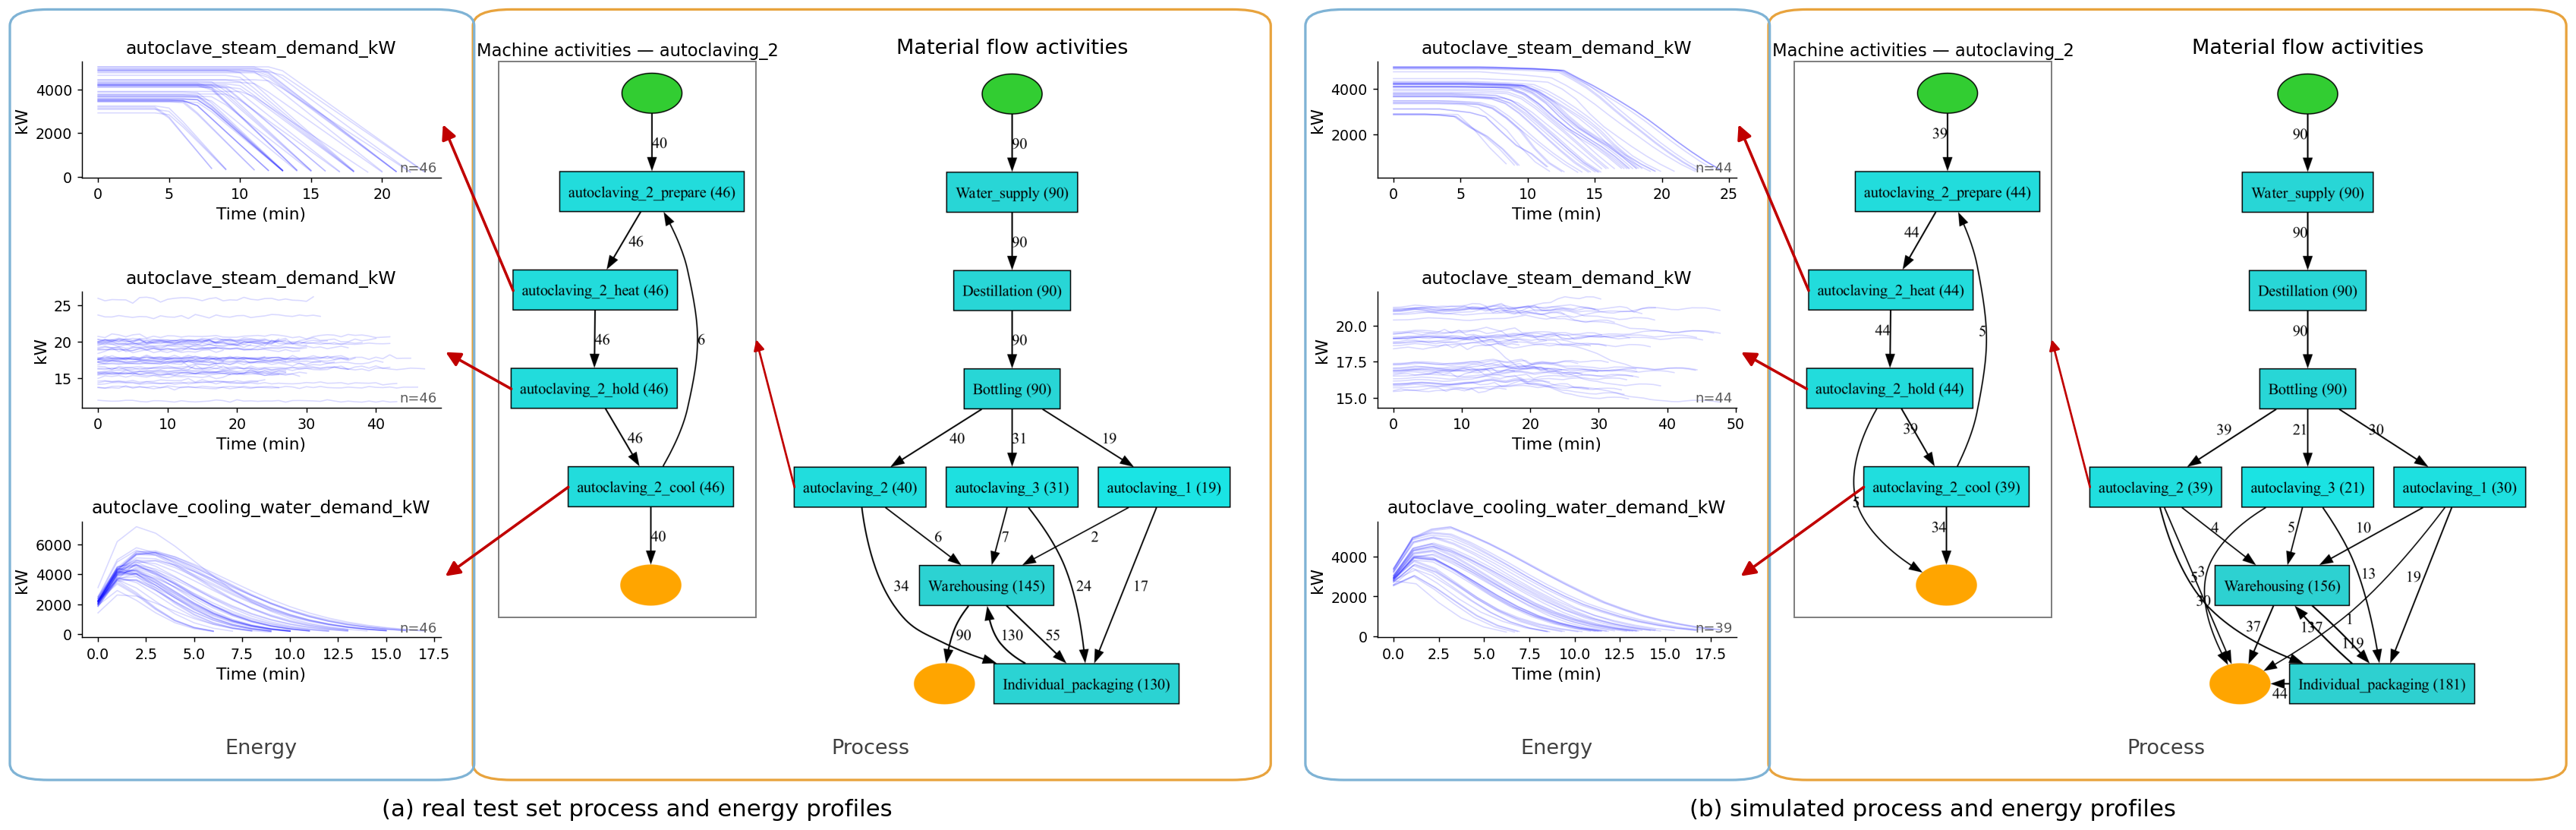

In [31]:
# ── Combined figure: (a) real | (b) simulated ────────────────────────────────
COMBINED_W, COMBINED_H = 26.0, 11.0  # inches; each block gets half the width
COMBINED_FS = 1.00                   # font scale inside a half-width block

# ONE plan for both halves -> same net scale, same panel width, so (a) and (b) are the same size
_plan = plan_blocks([BLOCK_REAL, BLOCK_SIM], COMBINED_W, COMBINED_H, rw=0.5, rh=1.0)
# Panel axes are NOT pinned across the halves: each panel autoscales on its own curves, so a
# profile is drawn at its own range instead of being squeezed into a shared one.
_lims = None

fig = plt.figure(figsize=(COMBINED_W, COMBINED_H))
draw_block(fig, (0.000, 0.0, 0.5, 1.0), BLOCK_REAL, CAPTION_REAL,
           COMBINED_W, COMBINED_H, _plan, fs=COMBINED_FS)
draw_block(fig, (0.505, 0.0, 0.5, 1.0), BLOCK_SIM, CAPTION_SIM,
           COMBINED_W, COMBINED_H, _plan, fs=COMBINED_FS)

if SAVE:
    _p = OUT / f'paper_figure_combined.pdf'
    fig.savefig(_p, format='pdf', bbox_inches='tight', pad_inches=0.15)
    print(f'saved {_p}')
plt.show()


## 5. Individual energy profiles — real vs every method

One panel per curve: the real profile of a single (process, sensor, activity)
execution and, on top of it, what every method predicted for that same curve.
Three curves per process, laid out in a grid of three columns.

The panels are selected deterministically, no hand-picking and no interactive
selector: per process they are the curves the BEST method — the approach with
the lowest Overall realism error in `03_results.ipynb` — reproduces most
faithfully. Degenerate curves are excluded first (see `IP_MIN_*` in the config),
and the sensor exclusions / panel cuts in the config pin the final set.

All identities are anonymised (same seed as `03_results.ipynb`, so the numbers
match the tables) and every panel is normalised to 0–1 on its own scale, so no
sensor names, company references, or physical units appear anywhere in the
figure. The point of a panel is the *shape*, not a comparison of levels between
panels. `realism` in the corner is the Overall realism error of the best method
on that curve: `err_f = |f(pred) - f(real)| / mean|f(real)|` over
Sum / Max / Mean / Std / Roughness, normalised per (process, sensor); Overall is
their mean, 0 = perfect.

In [32]:

# ── What to read ─────────────────────────────────────────────────────────────
IP_EXPERIMENT = 1     # experiment number; the latest run of it is used
IP_RUN        = None  # None = latest run of IP_EXPERIMENT; or a directory name
                      # / any substring of one, e.g. 'experiment_1_20260801'
IP_SPLIT      = 'TEST'   # 'TEST' | 'TRAIN' — the split the curves are drawn from

# ── The figure ───────────────────────────────────────────────────────────────
IP_N_PER_PROCESS = 3     # curves drawn per process
IP_N_COLS        = 3     # columns of the grid
IP_SAVE_PDF      = 'visuals/individual_profiles_grid.pdf'   # None = do not save

# Identity labels become shuffled numbers, with the SAME seed as 03_results.ipynb,
# so 'Process 4 / Sensor 12 / Activity 7' means the same thing in both.
IP_ANONYMISE = True
IP_ANON_SEED = 20260730

# ── Which method is 'best', and which methods are drawn ──────────────────────
# None = the approach with the lowest Overall realism, ranked exactly as the
# individual-profile table ranks it (median over cells of the per-cell median).
# Or pin one by its DISPLAY name, e.g. 'ML Step DTW (proposed)'.
IP_BEST_METHOD  = None
IP_SHOW_METHODS = None   # None = every approach in the run; or a list of display names
IP_EXCLUDE_APPROACHES = ['Exemplar (real curve)', 'Exemplar (no DTW)',
                         'Exemplar + DTW (warped)']     # raw names, dropped everywhere

# ── Which curves qualify ─────────────────────────────────────────────────────
# Without these the winners are all degenerate: a real curve that is flat zero
# scores a realism error of exactly 0 for every method, so the top of the ranking
# fills up with empty profiles that show nothing.
IP_MIN_CURVE_POINTS  = 15    # samples in the curve — long enough to have a shape
IP_MIN_REL_STD       = 0.02  # std|real| / max|real| — reject flat lines
IP_MIN_REL_MAGNITUDE = 0.25  # max|real| relative to the sensor's mean max|real| —
                             # reject curves that are near-zero for their sensor
IP_MIN_DUTY          = 0.10  # mean|real| / max|real| — reject a curve that is zero
                             # except for one spike: it passes the two filters
                             # above on the spike alone and draws an empty panel
IP_MAX_REALISM       = 0.50  # best-method realism ceiling — a curve missed this
                             # badly draws a failure panel, not a comparison
IP_DIVERSIFY = 'sensor+activity'   # 'sensor' | 'sensor+activity' | None — at most
                             # one curve per key, so a process does not show
                             # three executions of the same thing

# Sensors never drawn for a process, keyed by the DISPLAYED (anonymised) labels.
# On these processes the winners are intermittent on/off signals whose spikes
# rarely coincide, and every panel reads as noise; dropping the sensors hands
# the selection to batch-shaped curves the eye can actually follow.
IP_EXCLUDE_SENSORS = {
    'Process 1': ['Sensor 69', 'Sensor 71'],
    'Process 6': ['Sensor 16', 'Sensor 53'],
}

# Panels cut from the AUTOMATIC selection and not refilled — the figure is meant
# to get smaller, not to swap curves in. (Process, Sensor, Activity), displayed
# labels; every selected curve matching a triple is dropped.
IP_REMOVE_CURVES = [
    ('Process 3', 'Sensor 25', 'Activity 16'),
    ('Process 5', 'Sensor 46', 'Activity 29'),
    ('Process 6', 'Sensor 68', 'Activity 23'),
]

# ── Metrics behind the ranking (identical to 03_results.ipynb, section I) ────
IP_REALISM_SPECS = {
    'Sum':       ('sum_pred',   'sum_real'),    # total energy over the curve
    'Max':       ('max_pred',   'max_real'),    # peak — sizing and tariffs
    'Mean':      ('mean_pred',  'mean_real'),   # average load level = the bias
    'Std':       ('std_pred',   'std_real'),    # spread — the flatness measure
    'Roughness': ('rough_pred', 'rough_real'),  # jaggedness
}
IP_RANK_MIN_CURVE_POINTS = 5      # curve-length floor used for the RANKING only
IP_LEVEL_CELL_COVERAGE   = True   # rank on the cells every approach is scored on

# Paper naming — kept IDENTICAL to I_METHOD_RENAME in 03_results.ipynb, so a
# method is called the same thing in this figure and in the results tables.
IP_METHOD_RENAME = {
    'Step DTW smooth + ML + Ext.':    'ML Step DTW (proposed)',
    'Step DTW + ML + Ext.':           'Step DTW (step gains)',
    'ML + Ext. Factors':              'ML DTW (no steps)',
    'DTW + ML + Ext. Factors':        'ML DTW (no steps)',
    'ML DTW':                         'Step DTW w/o segments and ext.',
    'DTW + ML':                       'Step DTW w/o segments and ext.',
    'ML only (no DTW)':               'ML (no DTW)',
    'Median per Activity & Sensor':   'Median per Activity & Sensor',
    'Median per activity and sensor': 'Median per Activity & Sensor',
    'Baseline':                       'Sensor median',
    'DTW + Seq2Seq + Ext. Factors':   'Seq2Seq DTW (aligned)',
    'Seq2Seq IOM (DTW-selected)':     'Seq2Seq (DTW-scored)',
    'DTW + Seq2Seq':                  'Seq2Seq (aligned, w/o ext.)',
    'Seq2Seq only (no DTW)':          'Seq2Seq (unaligned)',
}


In [33]:

# ── Resolve the run and read the per-curve statistics (no curves yet) ─────────
import re, json, warnings
import numpy as np, pandas as pd
import pyarrow.dataset as ds, pyarrow.compute as pc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
warnings.filterwarnings('ignore')

IP_RESULTS_ROOT = Path('..') / 'results'

_ip_runs = sorted((d for d in IP_RESULTS_ROOT.iterdir()
                   if d.is_dir() and (d / 'curve_eval_results.parquet').exists()),
                  key=lambda d: d.name)
assert _ip_runs, 'no run with curve_eval_results.parquet'

# 'latest' is the latest TIMESTAMP, not the last name alphabetically: a run that
# has been renamed (experiment_1_old_20260730_...) still starts with the same
# experiment prefix and sorts after the newer one, which would silently read a
# superseded run. The name is matched strictly as experiment_<n>_<date>_<time>.
_IP_RUN_RE = re.compile(r'^experiment_(?P<exp>.+?)_(?P<stamp>\d{8}_\d{6})$')

def _ip_stamp(d):
    m = _IP_RUN_RE.match(d.name)
    return m.group('stamp') if m else ''

if IP_RUN:
    _match = ([d for d in _ip_runs if d.name == IP_RUN]
              or [d for d in _ip_runs if IP_RUN in d.name])
    assert _match, f'IP_RUN={IP_RUN!r} matches none of: ' + ', '.join(d.name for d in _ip_runs)
    ip_run_dir = max(_match, key=_ip_stamp)
else:
    _exp = [d for d in _ip_runs
            if (_m := _IP_RUN_RE.match(d.name)) and _m.group('exp') == str(IP_EXPERIMENT)]
    assert _exp, (f'no run named experiment_{IP_EXPERIMENT}_<date>_<time>; '
                  'set IP_RUN explicitly. Available: ' + ', '.join(d.name for d in _ip_runs))
    ip_run_dir = max(_exp, key=_ip_stamp)
print('Run:', ip_run_dir.name)

# Sample spacing, so the x axis can be minutes instead of sample numbers.
_info = (json.loads((ip_run_dir / 'info.json').read_text())
         if (ip_run_dir / 'info.json').exists() else {})
_res  = str(_info.get('temporal_resolution', '1min'))
_m    = re.fullmatch(r'(\d+)\s*min', _res)
IP_DT_MIN  = float(_m.group(1)) if _m else None      # None = unknown spacing
IP_X_LABEL = ('minutes since activity start' if IP_DT_MIN
              else f'samples since activity start ({_res})')
print(f'Temporal resolution: {_res}  ->  x axis in '
      + ('minutes' if IP_DT_MIN else 'samples'))

# Only the statistics columns — the curves themselves are read later, for the
# handful of instances that end up in the figure (the file holds ~400k of them).
_IP_STAT_COLS = ['Approach', 'Process', 'Sensor', 'Split', 'Activity', 'Instance', 'N',
                 'mean_real', 'std_real', 'max_real', 'rough_real',
                 'mean_pred', 'std_pred', 'max_pred', 'rough_pred']
ip_stats = pd.read_parquet(ip_run_dir / 'curve_eval_results.parquet',
                           columns=_IP_STAT_COLS)
ip_stats = ip_stats[ip_stats['Split'] == IP_SPLIT]
if IP_EXCLUDE_APPROACHES:
    ip_stats = ip_stats[~ip_stats['Approach'].isin(IP_EXCLUDE_APPROACHES)]
IP_CURVE_KEY = ['Process', 'Sensor', 'Activity', 'Instance']
print(f'{len(ip_stats):,} scored curves | {ip_stats["Approach"].nunique()} approaches | '
      f'{ip_stats.groupby(IP_CURVE_KEY).ngroups:,} distinct curves | '
      f'{ip_stats["Process"].nunique()} processes')

# ── Anonymisation maps, built exactly as 03_results.ipynb builds them ────────
# Same population (this split, exclusions applied), same seeds, same order — so a
# number here is the number the individual-profile table uses. Only these
# anonymised labels are ever displayed; the raw identities stay out of the
# figure, and no physical units are shown anywhere (panels are normalised).
def _ip_anon_map(values, prefix, seed):
    labels = sorted(pd.Series(values).dropna().astype(str).unique())
    order  = np.random.default_rng(seed).permutation(len(labels)) + 1
    return {lab: f'{prefix} {n}' for lab, n in zip(labels, order)}

IP_ANON = {}
if IP_ANONYMISE:
    _pair = ip_stats['Process'].astype(str) + ' | ' + ip_stats['Sensor'].astype(str)
    IP_ANON['Process']  = _ip_anon_map(ip_stats['Process'],  'Process',  IP_ANON_SEED + 0)
    IP_ANON['Activity'] = _ip_anon_map(ip_stats['Activity'], 'Activity', IP_ANON_SEED + 1)
    IP_ANON['Sensor']   = _ip_anon_map(_pair,                'Sensor',   IP_ANON_SEED + 2)
    print('Anonymised: ' + ', '.join(f'{k} ({len(v)})' for k, v in IP_ANON.items()))

def ip_label_process(p):
    return IP_ANON['Process'][str(p)] if IP_ANONYMISE else str(p)

def ip_label_activity(a):
    return IP_ANON['Activity'][str(a)] if IP_ANONYMISE else str(a)

def ip_label_sensor(p, s):
    return IP_ANON['Sensor'][f'{p} | {s}'] if IP_ANONYMISE else str(s)


Run: experiment_1_20260804_161749
Temporal resolution: 1min  ->  x axis in minutes
135,473 scored curves | 7 approaches | 19,403 distinct curves | 6 processes
Anonymised: Process (6), Activity (29), Sensor (79)


In [34]:

# ── The realism error of every (curve, approach), then the approach ranking ──
# err_f = |f(pred) - f(real)| / mean|f(real)| of that (process, sensor), so the
# five features are comparable and 0 is a perfect reproduction. The SCALE is the
# sensor's typical magnitude over the whole run, not this curve's own — dividing
# by the curve itself would make a tiny curve unmissable and a large one easy.
for _side in ('real', 'pred'):
    ip_stats[f'sum_{_side}'] = ip_stats[f'mean_{_side}'] * ip_stats['N']

_ip_uniq = ip_stats.drop_duplicates(['Process', 'Sensor', 'Instance', 'Activity'])
for _name, (_num, _den) in IP_REALISM_SPECS.items():
    _by = (_ip_uniq.groupby(['Process', 'Sensor'])[_den]
                   .apply(lambda s: pd.to_numeric(s, errors='coerce').abs().mean()))
    _scale = (pd.MultiIndex.from_arrays([ip_stats['Process'], ip_stats['Sensor']])
                .map(_by).to_numpy(dtype=float))
    ip_stats[_name] = np.where(np.isfinite(_scale) & (_scale > 1e-6),
                               (ip_stats[_num] - ip_stats[_den]).abs() / _scale, np.nan)

IP_METRICS = [m for m in IP_REALISM_SPECS if ip_stats[m].notna().any()]
ip_stats['Overall'] = ip_stats[IP_METRICS].mean(axis=1)
print('Realism metrics:', IP_METRICS)

# The ranking population: the same levelling the table uses, so the method called
# best here is the method the table calls best.
IP_CELL_KEY = ['Process', 'Activity', 'Sensor']
_rank = ip_stats[ip_stats['N'] >= IP_RANK_MIN_CURVE_POINTS]
if IP_LEVEL_CELL_COVERAGE:
    _cells = {a: set(map(tuple, g[IP_CELL_KEY].drop_duplicates().to_numpy()))
              for a, g in _rank.groupby('Approach')}
    _shared = set.intersection(*_cells.values()) if _cells else set()
    _rank = _rank[_rank[IP_CELL_KEY].apply(tuple, axis=1).isin(_shared)]
    print(f'Ranked on the {len(_shared)} (process, activity, sensor) cells every '
          f'approach is scored on')

_combo = _rank.groupby(IP_CELL_KEY + ['Approach'])[IP_METRICS].median().reset_index()
_combo['Overall'] = _combo[IP_METRICS].mean(axis=1)
ip_ranking = (_combo.groupby('Approach')[IP_METRICS + ['Overall']].median()
                    .sort_values('Overall')
                    .rename(index=IP_METHOD_RENAME).round(3))
ip_stats['Method'] = ip_stats['Approach'].replace(IP_METHOD_RENAME)

if IP_BEST_METHOD is None:
    IP_BEST_METHOD = ip_ranking.index[0]
assert IP_BEST_METHOD in set(ip_stats['Method']), \
    f'{IP_BEST_METHOD!r} is not in this run: {sorted(set(ip_stats["Method"]))}'
print(f'\nBest method: {IP_BEST_METHOD}   (lowest Overall realism error)\n')
display(ip_ranking)

# ── Per process: the curves IP_BEST_METHOD reproduces most faithfully ────────
# The candidate pool is filtered first. A real profile that is flat, or ~zero for
# its sensor, is matched perfectly by every method — those curves top the ranking
# without showing anything, so they are not eligible.
_best = ip_stats[ip_stats['Method'] == IP_BEST_METHOD].copy()
_sensor_scale = (_ip_uniq.groupby(['Process', 'Sensor'])['max_real']
                         .apply(lambda s: s.abs().mean()))
_best['rel_magnitude'] = (_best['max_real'].abs().to_numpy() /
                          pd.MultiIndex.from_arrays([_best['Process'], _best['Sensor']])
                            .map(_sensor_scale).to_numpy(dtype=float))
_best['rel_std'] = _best['std_real'].abs() / _best['max_real'].abs().replace(0, np.nan)
_best['duty']    = _best['mean_real'].abs() / _best['max_real'].abs().replace(0, np.nan)

_pool = _best[(_best['N'] >= IP_MIN_CURVE_POINTS)
              & (_best['max_real'].abs() > 1e-6)
              & (_best['rel_std'] >= IP_MIN_REL_STD)
              & (_best['rel_magnitude'] >= IP_MIN_REL_MAGNITUDE)
              & (_best['duty'] >= IP_MIN_DUTY)
              & (_best['Overall'] <= IP_MAX_REALISM)]
print(f'Candidate curves after the filters: {len(_pool):,} of {len(_best):,}')

if IP_EXCLUDE_SENSORS:
    _keep = [ip_label_sensor(p, s) not in IP_EXCLUDE_SENSORS.get(ip_label_process(p), ())
             for p, s in zip(_pool['Process'], _pool['Sensor'])]
    _pool = _pool[np.array(_keep)]
    print(f'After the per-process sensor exclusions: {len(_pool):,}')

_IP_DIV_KEY = {'sensor': ['Sensor'], 'sensor+activity': ['Sensor', 'Activity'],
               None: None, 'none': None}[IP_DIVERSIFY]

_rows = []
for _proc, _g in _pool.groupby('Process', sort=True):
    _taken, _seen = [], set()
    for _, _r in _g.sort_values('Overall').iterrows():
        if _IP_DIV_KEY:
            _k = tuple(_r[c] for c in _IP_DIV_KEY)
            if _k in _seen:
                continue
            _seen.add(_k)
        _taken.append(_r)
        if len(_taken) == IP_N_PER_PROCESS:
            break
    if len(_taken) < IP_N_PER_PROCESS:      # diversity before completeness: refill
        for _, _r in _g.sort_values('Overall').iterrows():   # from what is left
            if any(_r.name == t.name for t in _taken):
                continue
            _taken.append(_r)
            if len(_taken) == IP_N_PER_PROCESS:
                break
    if len(_taken) < IP_N_PER_PROCESS:
        print(f'  {_proc}: only {len(_taken)} curve(s) pass the filters')
    _rows += _taken

ip_selected = pd.DataFrame(_rows).reset_index(drop=True)
ip_selected['Process label']  = ip_selected['Process'].map(ip_label_process)
ip_selected['Sensor label']   = [ip_label_sensor(p, s) for p, s in
                                 zip(ip_selected['Process'], ip_selected['Sensor'])]
ip_selected['Activity label'] = ip_selected['Activity'].map(ip_label_activity)

# The cut list, applied AFTER the pick so the dropped panels are not refilled.
if IP_REMOVE_CURVES:
    _cut = ip_selected[['Process label', 'Sensor label', 'Activity label']].apply(
        tuple, axis=1).isin(set(IP_REMOVE_CURVES))
    ip_selected = ip_selected[~_cut].reset_index(drop=True)
    print(f'Removed {int(_cut.sum())} curve(s) via IP_REMOVE_CURVES')

# The figure numbers its panels in DISPLAYED process order (Process 1, 2, ...),
# not raw-name order — keep the dataframe in that same order, so 'panel (2)'
# means the same row everywhere.
def _ip_nat(s):
    return [int(t) if t.isdigit() else t for t in re.split(r'(\d+)', s)]
ip_selected = (ip_selected.loc[sorted(ip_selected.index,
                                      key=lambda i: _ip_nat(ip_selected.loc[i, 'Process label']))]
               .reset_index(drop=True))

print(f'\n{len(ip_selected)} curves selected — realism of {IP_BEST_METHOD} on each:')
display(ip_selected[['Process label', 'Sensor label', 'Activity label', 'Instance',
                     'N', 'Overall'] + IP_METRICS]
        .rename(columns={'Overall': 'Realism'}).round(3))


Realism metrics: ['Sum', 'Max', 'Mean', 'Std', 'Roughness']
Ranked on the 390 (process, activity, sensor) cells every approach is scored on

Best method: ML Step DTW (proposed)   (lowest Overall realism error)



,Sum,Max,Mean,Std,Roughness,Overall
Approach,,,,,,
ML Step DTW (proposed),0.017,0.065,0.046,0.373,0.467,0.229
ML (no DTW),0.018,0.072,0.050,0.424,0.542,0.278
ML DTW (no steps),0.017,0.064,0.051,0.428,0.530,0.284
Seq2Seq (DTW-scored),0.020,0.083,0.061,0.565,0.655,0.334
Seq2Seq DTW (aligned),0.018,0.080,0.057,0.592,0.667,0.334
Sensor median,0.014,0.067,0.041,0.518,0.745,0.337
Median per Activity & Sensor,0.014,0.070,0.042,0.518,0.745,0.338


Candidate curves after the filters: 2,882 of 19,345
After the per-process sensor exclusions: 2,643
Removed 3 curve(s) via IP_REMOVE_CURVES

15 curves selected — realism of ML Step DTW (proposed) on each:


,Process label,Sensor label,Activity label,Instance,N,Realism,Sum,Max,Mean,Std,Roughness
0,Process 1,Sensor 51,Activity 23,0,32,0.405,0.786,0.375,0.303,0.434,0.126
1,Process 1,Sensor 26,Activity 23,7,39,0.421,0.003,0.926,0.001,0.805,0.370
2,Process 1,Sensor 26,Activity 23,1,29,0.440,0.334,0.870,0.142,0.487,0.369
3,Process 2,Sensor 45,Activity 4,28,15,0.015,0.006,0.004,0.011,0.038,0.016
4,Process 2,Sensor 50,Activity 20,24,25,0.023,0.029,0.001,0.031,0.006,0.046
5,Process 2,Sensor 45,Activity 20,23,34,0.025,0.010,0.026,0.008,0.039,0.042
6,Process 3,Sensor 25,Activity 5,8,15,0.019,0.003,0.008,0.002,0.016,0.068
7,Process 3,Sensor 25,Activity 25,6,29,0.026,0.019,0.004,0.007,0.053,0.048
8,Process 4,Sensor 67,Activity 29,95,160,0.028,0.001,0.039,0.001,0.045,0.052
9,Process 4,Sensor 59,Activity 29,100,60,0.029,0.010,0.029,0.032,0.011,0.063


Loaded 15 curves | methods per curve: [7]
Methods drawn: ['ML Step DTW (proposed)', 'ML (no DTW)', 'ML DTW (no steps)', 'Seq2Seq (DTW-scored)', 'Seq2Seq DTW (aligned)', 'Sensor median', 'Median per Activity & Sensor']
Saved: visuals/individual_profiles_grid.pdf


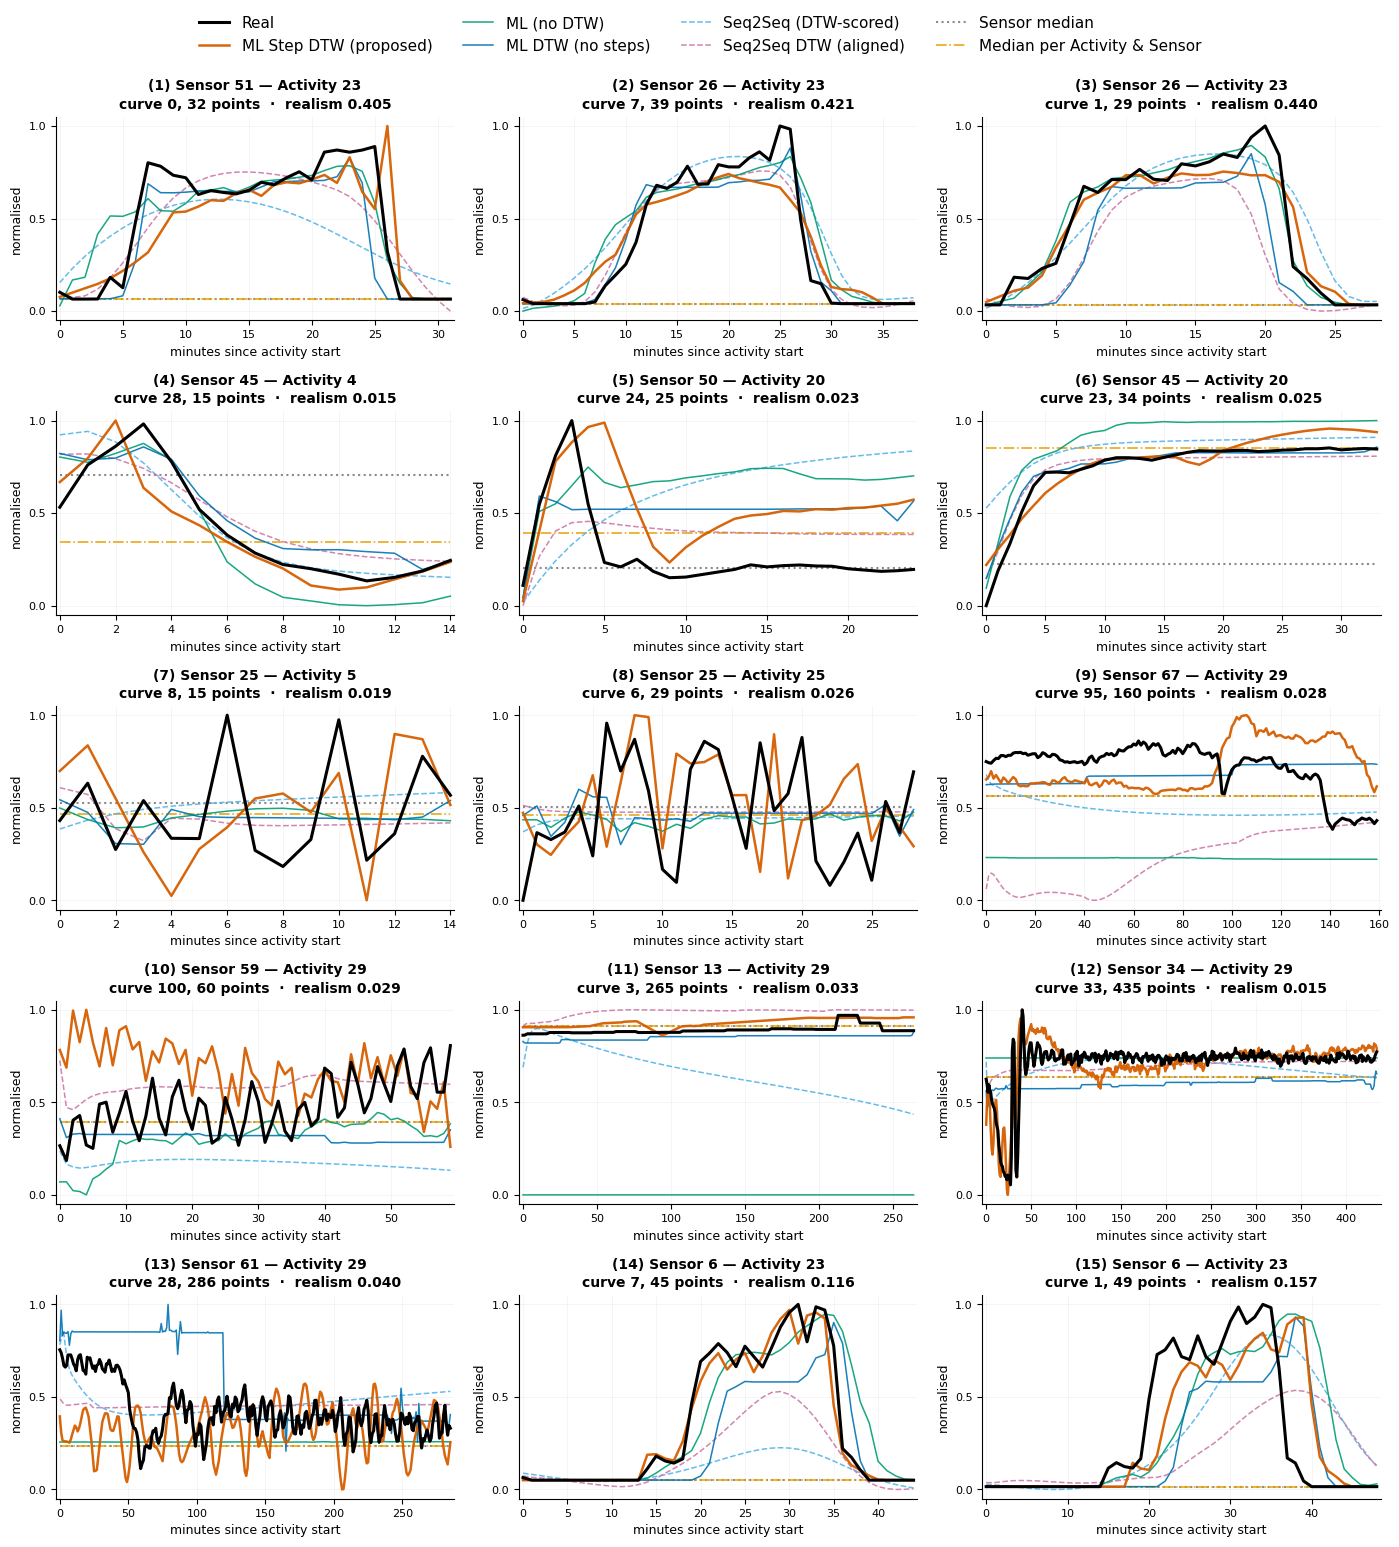

In [35]:

# ── Read the actual curves, for the selected instances only ──────────────────
# Both files carry one row per (process, sensor, activity, instance) — the
# predictions per approach, the real curve once — and every prediction is on the
# real curve's own grid, so a point index means the same time in all of them.
_pred_ds = ds.dataset(ip_run_dir / 'curve_eval_results.parquet')
_real_ds = ds.dataset(ip_run_dir / 'real_test_curves.parquet')

_filter = None
for _proc, _g in ip_selected.groupby('Process'):
    _f = (pc.field('Process') == _proc) & pc.field('Instance').isin(
        [int(i) for i in _g['Instance'].unique()])
    _filter = _f if _filter is None else (_filter | _f)
_filter = _filter & (pc.field('Split') == IP_SPLIT)

_pred = (_pred_ds.to_table(filter=_filter,
                           columns=IP_CURVE_KEY + ['Approach', 'N', 'y_pred'])
                 .to_pandas())
_real = (_real_ds.to_table(filter=_filter, columns=IP_CURVE_KEY + ['N', 'y_real'])
                 .to_pandas())
if IP_EXCLUDE_APPROACHES:
    _pred = _pred[~_pred['Approach'].isin(IP_EXCLUDE_APPROACHES)]
_pred['Method'] = _pred['Approach'].replace(IP_METHOD_RENAME)

# The filter is a coarse (process, instance) net — keep the exact curves only.
_want = set(map(tuple, ip_selected[IP_CURVE_KEY].to_numpy()))
_pred = _pred[_pred[IP_CURVE_KEY].apply(tuple, axis=1).isin(_want)]
_real = _real[_real[IP_CURVE_KEY].apply(tuple, axis=1).isin(_want)]

IP_CURVES = {}       # (process, sensor, activity, instance) -> {series -> array}
for _k, _g in _real.groupby(IP_CURVE_KEY):
    IP_CURVES[_k] = {'Real': np.asarray(_g.iloc[0]['y_real'], dtype=float)}
for _k, _g in _pred.groupby(IP_CURVE_KEY):
    IP_CURVES.setdefault(_k, {}).update(
        {r['Method']: np.asarray(r['y_pred'], dtype=float) for _, r in _g.iterrows()})

_missing = [k for k in _want if 'Real' not in IP_CURVES.get(k, {})]
if _missing:
    print(f'!! no real curve for {len(_missing)} selection(s): {_missing}')
print(f'Loaded {len(IP_CURVES)} curves | methods per curve: '
      f'{sorted({len(v) - 1 for v in IP_CURVES.values()})}')

IP_METHODS_PRESENT = [m for m in ip_ranking.index if m in set(_pred['Method'])]
IP_DRAW_METHODS = ([m for m in IP_SHOW_METHODS if m in IP_METHODS_PRESENT]
                   if IP_SHOW_METHODS else IP_METHODS_PRESENT)
IP_DRAW_METHODS = [IP_BEST_METHOD] + [m for m in IP_DRAW_METHODS
                                      if m != IP_BEST_METHOD]
print('Methods drawn:', IP_DRAW_METHODS)

# ── Style ────────────────────────────────────────────────────────────────────
# One visual FORM per method family — colour only separates within a family:
#   solid    = the ML / Step DTW family (the proposed method is the thick one)
#   dashed   = the Seq2Seq family
#   dash-dot = the activity-level median
#   dotted   = the sensor-level baseline, the ONLY dotted line in the figure
# Real stays the only black, heavy line, so the reference is unmistakable.
# Colours are Okabe-Ito (colour-blind safe).
plt.rcParams.update(plt.rcParamsDefault)

IP_REAL_STYLE = dict(color='black', linestyle='-', linewidth=2.2, zorder=10)

_IP_FAMILY_STYLE = {
    'ML Step DTW (proposed)':         dict(color='#D55E00', linestyle='-',
                                           linewidth=1.8, alpha=0.95, zorder=9),
    'ML DTW (no steps)':              dict(color='#0072B2', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'ML (no DTW)':                    dict(color='#009E73', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'Step DTW (step gains)':          dict(color='#CC79A7', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'Step DTW w/o segments and ext.': dict(color='#E69F00', linestyle='-',
                                           linewidth=1.1, alpha=0.9, zorder=8),
    'Seq2Seq DTW (aligned)':          dict(color='#CC79A7', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Seq2Seq (DTW-scored)':           dict(color='#56B4E9', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Seq2Seq (aligned, w/o ext.)':    dict(color='#E69F00', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Seq2Seq (unaligned)':            dict(color='#999999', linestyle='--',
                                           linewidth=1.1, alpha=0.9, zorder=7),
    'Median per Activity & Sensor':   dict(color='#E69F00', linestyle='-.',
                                           linewidth=1.2, alpha=0.9, zorder=6),
    'Sensor median':                  dict(color='#7F7F7F', linestyle=':',
                                           linewidth=1.5, alpha=0.9, zorder=5),
}
_IP_FALLBACK = ['#666666', '#8C510A', '#01665E']
IP_SERIES_STYLE = {m: _IP_FAMILY_STYLE.get(m, dict(color=_IP_FALLBACK[i % len(_IP_FALLBACK)],
                                                   linestyle='-', linewidth=0.9,
                                                   alpha=0.8, zorder=4))
                   for i, m in enumerate(IP_DRAW_METHODS)}

IP_FS = {'legend': 11, 'title': 10, 'axis': 9, 'tick': 8, 'note': 8}

def draw_profile_panel(ax, key, row, num=None):
    """One curve: the real profile in black, every method over it."""
    series = IP_CURVES.get(key, {})
    real = series.get('Real')
    if real is None or len(real) == 0:
        ax.text(0.5, 0.5, 'no real curve', ha='center', va='center',
                transform=ax.transAxes, fontsize=IP_FS['note'], color='#888888')
        ax.set_xticks([]); ax.set_yticks([])
        return

    def _x(v):
        return np.arange(len(v)) * (IP_DT_MIN if IP_DT_MIN else 1.0)

    # Every panel is scaled to 0–1 over ALL its series, so no physical unit is
    # shown. The span covers every method, never just the real one: a method
    # that predicts far off the real level has to stay visible — that offset is
    # the error the panel is about — so the real curve alone need not reach 1.
    _series = [(m, series[m]) for m in IP_DRAW_METHODS
               if series.get(m) is not None and len(series[m])]
    _lo = min(float(np.nanmin(v)) for _, v in [('Real', real)] + _series)
    _hi = max(float(np.nanmax(v)) for _, v in [('Real', real)] + _series)
    _span = (_hi - _lo) if _hi > _lo else max(abs(_hi), 1.0)

    def _n(v):
        return (np.asarray(v, dtype=float) - _lo) / _span

    ax.plot(_x(real), _n(real), label='Real', **IP_REAL_STYLE)
    for m, v in _series:
        ax.plot(_x(v), _n(v), label=m, **IP_SERIES_STYLE[m])

    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.5, 1])

    _no = f'({num}) ' if num is not None else ''
    ax.set_title(f'{_no}{row["Sensor label"]} — {row["Activity label"]}\n'
                 f'curve {int(row["Instance"])}, {int(row["N"])} points  ·  '
                 f'realism {row["Overall"]:.3f}',
                 fontsize=IP_FS['title'], fontweight='bold', linespacing=1.4)
    ax.set_ylabel('normalised', fontsize=IP_FS['axis'])
    ax.set_xlabel(IP_X_LABEL, fontsize=IP_FS['axis'])
    ax.tick_params(labelsize=IP_FS['tick'])
    ax.margins(x=0.01)
    ax.grid(alpha=0.15, linewidth=0.6)
    for _s in ('top', 'right'):
        ax.spines[_s].set_visible(False)

# ── Layout: panels flow through the grid, IP_N_COLS wide ─────────────────────
# ip_selected is already in displayed process order, so panels stay grouped by
# process even without row labels (removed on purpose — no process names in the
# figure). Panels are numbered (1), (2), ... in reading order, so the text can
# point at one.
def render_profile_grid():
    _n = len(ip_selected)
    _nrows = int(np.ceil(_n / IP_N_COLS))

    fig, axes = plt.subplots(_nrows, IP_N_COLS,
                             figsize=(4.7 * IP_N_COLS, 3.1 * _nrows))
    axes = np.atleast_2d(axes)

    for _i in range(_nrows * IP_N_COLS):
        _ax = axes[_i // IP_N_COLS, _i % IP_N_COLS]
        if _i < _n:
            draw_profile_panel(_ax, tuple(ip_selected.loc[_i, IP_CURVE_KEY]),
                               ip_selected.loc[_i], num=_i + 1)
        else:
            _ax.axis('off')

    handles = ([Line2D([0], [0], label='Real', **IP_REAL_STYLE)] +
               [Line2D([0], [0], label=m, **IP_SERIES_STYLE[m])
                for m in IP_DRAW_METHODS])
    fig.legend(handles=handles, labels=[h.get_label() for h in handles],
               loc='upper center', ncol=min(4, len(handles)), frameon=False,
               fontsize=IP_FS['legend'], bbox_to_anchor=(0.5, 1.0))

    _leg_rows = int(np.ceil(len(handles) / min(4, len(handles))))
    fig.tight_layout(rect=[0, 0, 1, 1 - 0.020 * _leg_rows])

    if IP_SAVE_PDF:
        Path(IP_SAVE_PDF).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(IP_SAVE_PDF, format='pdf', bbox_inches='tight', dpi=300,
                    facecolor='white')
        print('Saved:', IP_SAVE_PDF)
    plt.close(fig)
    return fig

display(render_profile_grid())
